# Credit Risk & Loan Default Prediction
## End-to-End Analytics & Machine Learning Pipeline

**Author:** Sanju Thomas Sabu  
**Program:** Master of Business Analytics, University of Wollongong in Dubai  
**Dataset:** Give Me Some Credit — Kaggle  
**Tools:** Python, SQLite, Scikit-learn, XGBoost, SHAP, Power BI  

---

### Business Context

Loan defaults represent one of the most significant risks facing banks and financial institutions globally. Non-performing loans (NPLs) drain capital reserves, reduce profitability, and in extreme cases threaten institutional stability. In the UAE, the Central Bank has consistently flagged credit risk as a top supervisory priority, with NPL ratios closely monitored across retail and corporate lending portfolios.

This project builds an end-to-end credit risk analytics pipeline — from raw data ingestion and SQL-based business analysis, through exploratory analysis and feature engineering, to a machine learning model capable of predicting which loan applicants are most likely to default. The final output includes SHAP-based model explainability and an executive Power BI dashboard designed for a bank's risk management team.

---

### Project Phases
- **Phase 1** — Data Ingestion & SQL Foundation  
- **Phase 2** — Data Cleaning & Feature Engineering  
- **Phase 3** — Exploratory Data Analysis  
- **Phase 4** — Machine Learning Pipeline & SHAP Explainability  
- **Phase 5** — Power BI Dashboard  
- **Phase 6** — Business Recommendations & Executive Summary

In [2]:
# =============================================================================
# PHASE 1 — DATA INGESTION & SQL FOUNDATION
# =============================================================================
# This cell imports all libraries needed across the entire project.
# Importing everything upfront keeps the notebook clean and makes
# dependency issues easy to spot early.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')

# Set consistent visual style for all charts throughout the project
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 150

print("✅ All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully
Pandas version: 2.2.3
NumPy version: 2.2.2


### Step 1.1 — Load Raw Data

We begin by loading the raw CSV into a Pandas DataFrame to do a first inspection
of the data — shape, column names, data types, and a preview of the first few rows.
This confirms the file loaded correctly before we do anything else.

In [3]:
# Load the raw CSV from the /data folder
# Using a relative path so the notebook works on any machine
df_raw = pd.read_csv('../data/cs-training.csv')

# Drop the unnamed index column Kaggle includes by default
df_raw = df_raw.drop(columns=['Unnamed: 0'])

# Basic shape check
print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("\n--- Column Names & Data Types ---")
print(df_raw.dtypes)
print("\n--- First 5 Rows ---")
df_raw.head()

Dataset shape: 150,000 rows × 11 columns

--- Column Names & Data Types ---
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

--- First 5 Rows ---


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### Step 1.2 — Data Quality Summary

Before ingesting into SQLite, we run a quick quality check to understand:
- How many missing values exist and in which columns
- Basic descriptive statistics to spot anything obviously wrong
- The class balance of our target variable (SeriousDlqin2yrs)

In [4]:
# --- Missing Values ---
print("=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# --- Basic Statistics ---
print("\n=== Descriptive Statistics ===")
print(df_raw.describe().round(2))

# --- Target Variable Distribution ---
print("\n=== Target Variable Distribution ===")
target_counts = df_raw['SeriousDlqin2yrs'].value_counts()
target_pct = df_raw['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct.round(2)
})
target_summary.index = ['No Default (0)', 'Default (1)']
print(target_summary)

=== Missing Values ===
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62

=== Descriptive Statistics ===
       SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines        age  \
count         150000.00                             150000.00  150000.00   
mean               0.07                                  6.05      52.30   
std                0.25                                249.76      14.77   
min                0.00                                  0.00       0.00   
25%                0.00                                  0.03      41.00   
50%                0.00                                  0.15      52.00   
75%                0.00                                  0.56      63.00   
max                1.00                              50708.00     109.00   

       NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
count                             150000.00  150000.

### Step 1.3 — Ingest Raw Data into SQLite

We load the raw dataset into a SQLite database. This creates a permanent,
queryable data store that mirrors how data would sit in a bank's internal
database system. All business queries in the next step will run directly
against this database using SQL — not Pandas — to demonstrate SQL proficiency
alongside Python.

In [5]:
# Define path for the SQLite database — stored in the /data folder
db_path = '../data/credit_risk.db'

# Create a connection to SQLite (creates the .db file if it doesn't exist)
conn = sqlite3.connect(db_path)

# Write the raw DataFrame into a table called 'loan_applicants'
# if_exists='replace' means re-running this cell won't cause duplicates
df_raw.to_sql('loan_applicants', conn, if_exists='replace', index=False)

# Verify the table was created and row count is correct
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM loan_applicants")
row_count = cursor.fetchone()[0]

print(f"✅ SQLite database created at: {db_path}")
print(f"✅ Table 'loan_applicants' created with {row_count:,} rows")

# Keep connection open — we'll use it for SQL queries in the next step

✅ SQLite database created at: ../data/credit_risk.db
✅ Table 'loan_applicants' created with 150,000 rows


### Step 1.4 — Business SQL Queries

We execute 8 business-focused SQL queries directly against the SQLite database.
Each query is designed to answer a specific question a bank's credit risk team
would ask about their loan portfolio.

In [6]:
# Helper function to run any SQL query and return a clean DataFrame
# This avoids repeating the same boilerplate for every query
def run_query(query, description=""):
    if description:
        print(f"\n{'='*60}")
        print(f" {description}")
        print(f"{'='*60}")
    result = pd.read_sql_query(query, conn)
    return result

# --- Query 1: Overall Default Rate ---
q1 = """
SELECT
    COUNT(*) AS total_applicants,
    SUM(SeriousDlqin2yrs) AS total_defaults,
    ROUND(100.0 * SUM(SeriousDlqin2yrs) / COUNT(*), 2) AS default_rate_pct
FROM loan_applicants;
"""
df_q1 = run_query(q1, "Q1: Overall Portfolio Default Rate")
display(df_q1)

# --- Query 2: Default Rate by Age Band ---
q2 = """
SELECT
    CASE
        WHEN age < 30 THEN 'Under 30'
        WHEN age BETWEEN 30 AND 44 THEN '30-44'
        WHEN age BETWEEN 45 AND 59 THEN '45-59'
        WHEN age BETWEEN 60 AND 74 THEN '60-74'
        ELSE '75+'
    END AS age_band,
    COUNT(*) AS total_applicants,
    SUM(SeriousDlqin2yrs) AS total_defaults,
    ROUND(100.0 * SUM(SeriousDlqin2yrs) / COUNT(*), 2) AS default_rate_pct
FROM loan_applicants
WHERE age > 0
GROUP BY age_band
ORDER BY default_rate_pct DESC;
"""
df_q2 = run_query(q2, "Q2: Default Rate by Age Band")
display(df_q2)


 Q1: Overall Portfolio Default Rate


,total_applicants,total_defaults,default_rate_pct
0,150000,10026,6.68



 Q2: Default Rate by Age Band


,age_band,total_applicants,total_defaults,default_rate_pct
0,Under 30,8820,1035,11.73
1,30-44,38982,3700,9.49
2,45-59,53879,3791,7.04
3,60-74,36948,1271,3.44
4,75+,11370,229,2.01


In [7]:
# --- Query 3: Avg Debt Ratio and Income by Default Status ---
q3 = """
SELECT
    CASE WHEN SeriousDlqin2yrs = 1 THEN 'Defaulted' ELSE 'No Default' END AS default_status,
    ROUND(AVG(DebtRatio), 4) AS avg_debt_ratio,
    ROUND(AVG(MonthlyIncome), 2) AS avg_monthly_income,
    COUNT(*) AS total_applicants
FROM loan_applicants
GROUP BY SeriousDlqin2yrs;
"""
df_q3 = run_query(q3, "Q3: Average Debt Ratio and Income by Default Status")
display(df_q3)

# --- Query 4: High-Risk Segment Isolation ---
q4 = """
SELECT
    COUNT(*) AS high_risk_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM loan_applicants), 2) AS pct_of_portfolio,
    ROUND(AVG(MonthlyIncome), 2) AS avg_income,
    ROUND(AVG(DebtRatio), 4) AS avg_debt_ratio
FROM loan_applicants
WHERE RevolvingUtilizationOfUnsecuredLines > 0.8
  AND DebtRatio > 0.5
  AND SeriousDlqin2yrs = 1;
"""
df_q4 = run_query(q4, "Q4: High-Risk Segment — High Utilization + High Debt + Defaulted")
display(df_q4)

# --- Query 5: Late Payment History vs Default Status ---
q5 = """
SELECT
    CASE WHEN SeriousDlqin2yrs = 1 THEN 'Defaulted' ELSE 'No Default' END AS default_status,
    ROUND(AVG("NumberOfTime30-59DaysPastDueNotWorse"), 4) AS avg_30_59_late,
    ROUND(AVG(NumberOfTimes90DaysLate), 4) AS avg_90_days_late,
    ROUND(AVG("NumberOfTime60-89DaysPastDueNotWorse"), 4) AS avg_60_89_late,
    COUNT(*) AS total
FROM loan_applicants
GROUP BY SeriousDlqin2yrs;
"""
df_q5 = run_query(q5, "Q5: Late Payment History by Default Status")
display(df_q5)


 Q3: Average Debt Ratio and Income by Default Status


,default_status,avg_debt_ratio,avg_monthly_income,total_applicants
0,No Default,357.1512,6747.84,139974
1,Defaulted,295.1211,5630.83,10026



 Q4: High-Risk Segment — High Utilization + High Debt + Defaulted


,high_risk_count,pct_of_portfolio,avg_income,avg_debt_ratio
0,2253,1.5,4676.53,602.2554



 Q5: Late Payment History by Default Status


,default_status,avg_30_59_late,avg_90_days_late,avg_60_89_late,total
0,No Default,0.2801,0.1352,0.1267,139974
1,Defaulted,2.3885,2.0914,1.8280,10026


In [8]:
# --- Query 6: Default Rate by Utilization Band ---
q6 = """
SELECT
    CASE
        WHEN RevolvingUtilizationOfUnsecuredLines <= 0.25 THEN 'Low (0-25%)'
        WHEN RevolvingUtilizationOfUnsecuredLines <= 0.50 THEN 'Moderate (25-50%)'
        WHEN RevolvingUtilizationOfUnsecuredLines <= 0.75 THEN 'High (50-75%)'
        WHEN RevolvingUtilizationOfUnsecuredLines <= 1.00 THEN 'Very High (75-100%)'
        ELSE 'Extreme (>100%)'
    END AS utilization_band,
    COUNT(*) AS total_applicants,
    SUM(SeriousDlqin2yrs) AS total_defaults,
    ROUND(100.0 * SUM(SeriousDlqin2yrs) / COUNT(*), 2) AS default_rate_pct
FROM loan_applicants
GROUP BY utilization_band
ORDER BY default_rate_pct DESC;
"""
df_q6 = run_query(q6, "Q6: Default Rate by Credit Utilization Band")
display(df_q6)

# --- Query 7: Default Rate by Number of Dependents ---
q7 = """
SELECT
    CAST(NumberOfDependents AS INTEGER) AS num_dependents,
    COUNT(*) AS total_applicants,
    SUM(SeriousDlqin2yrs) AS total_defaults,
    ROUND(100.0 * SUM(SeriousDlqin2yrs) / COUNT(*), 2) AS default_rate_pct
FROM loan_applicants
WHERE NumberOfDependents IS NOT NULL
GROUP BY num_dependents
ORDER BY num_dependents;
"""
df_q7 = run_query(q7, "Q7: Default Rate by Number of Dependents")
display(df_q7)

# --- Query 8: Default Rate by Income Band ---
q8 = """
SELECT
    CASE
        WHEN MonthlyIncome < 2000 THEN 'Under $2K'
        WHEN MonthlyIncome BETWEEN 2000 AND 4999 THEN '$2K-$5K'
        WHEN MonthlyIncome BETWEEN 5000 AND 9999 THEN '$5K-$10K'
        WHEN MonthlyIncome BETWEEN 10000 AND 19999 THEN '$10K-$20K'
        ELSE 'Above $20K'
    END AS income_band,
    COUNT(*) AS total_applicants,
    SUM(SeriousDlqin2yrs) AS total_defaults,
    ROUND(100.0 * SUM(SeriousDlqin2yrs) / COUNT(*), 2) AS default_rate_pct
FROM loan_applicants
WHERE MonthlyIncome IS NOT NULL
GROUP BY income_band
ORDER BY default_rate_pct DESC;
"""
df_q8 = run_query(q8, "Q8: Default Rate by Monthly Income Band")
display(df_q8)

print("\n✅ All 8 SQL queries executed successfully")


 Q6: Default Rate by Credit Utilization Band


,utilization_band,total_applicants,total_defaults,default_rate_pct
0,Extreme (>100%),3321,1237,37.25
1,Very High (75-100%),24203,4408,18.21
2,High (50-75%),13764,1394,10.13
3,Moderate (25-50%),21055,1114,5.29
4,Low (0-25%),87657,1873,2.14



 Q7: Default Rate by Number of Dependents


,num_dependents,total_applicants,total_defaults,default_rate_pct
0,0,86902,5095,5.86
1,1,26316,1935,7.35
2,2,19522,1584,8.11
3,3,9483,837,8.83
4,4,2862,297,10.38
5,5,746,68,9.12
6,6,158,24,15.19
7,7,51,5,9.80
8,8,24,2,8.33
9,9,5,0,0.00



 Q8: Default Rate by Monthly Income Band


,income_band,total_applicants,total_defaults,default_rate_pct
0,$2K-$5K,42215,3736,8.85
1,Under $2K,10887,914,8.40
2,$5K-$10K,47382,2851,6.02
3,Above $20K,2329,121,5.20
4,$10K-$20K,17456,735,4.21



✅ All 8 SQL queries executed successfully


---
## Phase 2 — Data Cleaning & Feature Engineering

### Step 2.1 — Working Copy & Missing Value Treatment

We create a working copy of the raw DataFrame so the original data is always
preserved for reference. This is standard practice in any professional analytics
pipeline — never overwrite raw data.

**Missing Value Strategy: Median Imputation**

Two columns have missing values:
- `MonthlyIncome` — 19.82% missing (29,731 rows)
- `NumberOfDependents` — 2.62% missing (3,924 rows)

We use **median imputation** rather than mean imputation for both columns because:
- Both distributions are heavily right-skewed (confirmed by the max values we saw
  in descriptive statistics — income up to $3M, dependents up to 20)
- The median is resistant to extreme outliers; the mean would be pulled upward
  by the extreme values and produce an unrealistic imputed value
- For a bank, imputing a more conservative (lower) central value is also the
  more prudent assumption when income data is unknown

In [9]:
# =============================================================================
# PHASE 2 — DATA CLEANING & FEATURE ENGINEERING
# =============================================================================

# Create a working copy — raw data is never modified
df = df_raw.copy()

print("=== Before Imputation ===")
print(f"MonthlyIncome missing: {df['MonthlyIncome'].isnull().sum():,}")
print(f"NumberOfDependents missing: {df['NumberOfDependents'].isnull().sum():,}")

# Calculate medians from non-null values
median_income = df['MonthlyIncome'].median()
median_dependents = df['NumberOfDependents'].median()

print(f"\nMedian MonthlyIncome: ${median_income:,.2f}")
print(f"Median NumberOfDependents: {median_dependents}")

# Apply median imputation
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(median_income)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(median_dependents)

print("\n=== After Imputation ===")
print(f"MonthlyIncome missing: {df['MonthlyIncome'].isnull().sum()}")
print(f"NumberOfDependents missing: {df['NumberOfDependents'].isnull().sum()}")
print("\n✅ Missing values treated successfully")

=== Before Imputation ===
MonthlyIncome missing: 29,731
NumberOfDependents missing: 3,924

Median MonthlyIncome: $5,400.00
Median NumberOfDependents: 0.0

=== After Imputation ===
MonthlyIncome missing: 0
NumberOfDependents missing: 0

✅ Missing values treated successfully


### Step 2.2 — Outlier Detection & Treatment

We use the **IQR (Interquartile Range) method** to detect and cap outliers.
Rather than deleting outlier rows (which would lose data), we apply **Winsorization
— capping values at the 1st and 99th percentile**. This preserves all 150,000
rows while preventing extreme values from distorting model training.

Columns treated and business justification for each:
- `RevolvingUtilizationOfUnsecuredLines` — max of 50,708 is physically impossible
  for a utilization ratio. Values above 1.0 are data errors. Capped at 99th percentile.
- `DebtRatio` — max of 329,664 is nonsensical. A debt ratio above ~10 is already
  extreme. Capped at 99th percentile.
- `MonthlyIncome` — max of $3,008,750 would dominate model training. Capped at
  99th percentile to retain high earners without distortion.
- `NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`,
  `NumberOfTime60-89DaysPastDueNotWorse` — max of 98 is a known encoding artifact
  in this dataset (98 and 96 are placeholder values). Capped at 99th percentile.
- `age` — minimum of 0 is impossible. Any age below 18 is also invalid for a loan
  applicant. These rows are filtered out.

In [10]:
# --- Step 1: Remove invalid age rows (age < 18) ---
invalid_age = (df['age'] < 18).sum()
print(f"Rows with age < 18: {invalid_age} — removing these")
df = df[df['age'] >= 18].copy()
print(f"Dataset shape after age filter: {df.shape}")

# --- Step 2: Winsorize using 1st and 99th percentile caps ---
# Columns to cap — chosen based on descriptive stats review in Phase 1
cols_to_cap = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

print("\n=== Outlier Capping Summary (1st–99th Percentile) ===")
print(f"{'Column':<45} {'Old Max':>12} {'New Max':>12} {'Old Min':>10} {'New Min':>10}")
print("-" * 95)

for col in cols_to_cap:
    old_min = df[col].min()
    old_max = df[col].max()
    
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    
    df[col] = df[col].clip(lower=lower, upper=upper)
    
    new_min = df[col].min()
    new_max = df[col].max()
    
    print(f"{col:<45} {old_max:>12.2f} {new_max:>12.2f} {old_min:>10.2f} {new_min:>10.2f}")

print(f"\n✅ Outlier treatment complete")
print(f"Final dataset shape: {df.shape}")

Rows with age < 18: 1 — removing these
Dataset shape after age filter: (149999, 11)

=== Outlier Capping Summary (1st–99th Percentile) ===
Column                                             Old Max      New Max    Old Min    New Min
-----------------------------------------------------------------------------------------------
RevolvingUtilizationOfUnsecuredLines              50708.00         1.09       0.00       0.00
DebtRatio                                        329664.00      4979.08       0.00       0.00
MonthlyIncome                                   3008750.00     23000.00       0.00       0.00
NumberOfTime30-59DaysPastDueNotWorse                 98.00         4.00       0.00       0.00
NumberOfTimes90DaysLate                              98.00         3.00       0.00       0.00
NumberOfTime60-89DaysPastDueNotWorse                 98.00         2.00       0.00       0.00

✅ Outlier treatment complete
Final dataset shape: (149999, 11)


### Step 2.3 — Feature Engineering

We engineer 5 new features that transform raw data points into signals a credit
risk analyst would actually use when assessing an applicant. Each feature is
designed to capture a dimension of risk that no single raw column fully represents.

| Feature | Type | Business Rationale |
|---|---|---|
| `TotalLatePayments` | Numeric | Aggregates all late payment history into one risk signal |
| `DebtToIncomeRatio` | Numeric | Monthly debt burden relative to income — core affordability metric |
| `CreditStressScore` | Numeric | Composite score combining utilization and late payments |
| `HighUtilization` | Binary flag | Flags applicants above 80% utilization — a known default trigger |
| `AgeGroup` | Categorical | Bins age into segments for risk tiering and dashboard segmentation |

**Why these features matter to a bank:**
- `TotalLatePayments` — A single missed payment is noise. A pattern of missed
  payments across multiple windows is a strong behavioural signal.
- `DebtToIncomeRatio` — The UAE Central Bank uses debt burden ratio as a key
  affordability measure in retail lending regulations.
- `CreditStressScore` — Combines two independently strong predictors into one
  composite score, useful for quick applicant triage.
- `HighUtilization` — Binary flags are easy to operationalise in loan origination
  systems as hard rules (e.g. auto-decline if HighUtilization = 1 AND late payments > 2).
- `AgeGroup` — Enables age-based segmentation in dashboards and policy rules
  without treating age as a continuous variable.

In [11]:
# --- Feature 1: TotalLatePayments ---
# Sum of all three late payment columns — captures overall delinquency behaviour
df['TotalLatePayments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate'] +
    df['NumberOfTime60-89DaysPastDueNotWorse']
)

# --- Feature 2: DebtToIncomeRatio ---
# Monthly debt obligations relative to income
# We add 1 to MonthlyIncome to avoid division by zero for any $0 income rows
df['DebtToIncomeRatio'] = df['DebtRatio'] / (df['MonthlyIncome'] + 1)

# --- Feature 3: CreditStressScore ---
# Composite score: normalised utilization + normalised late payments
# Both components scaled to 0-1 range before combining so neither dominates
util_scaled = df['RevolvingUtilizationOfUnsecuredLines'] / df['RevolvingUtilizationOfUnsecuredLines'].max()
late_scaled = df['TotalLatePayments'] / (df['TotalLatePayments'].max() + 1)
df['CreditStressScore'] = (util_scaled + late_scaled) / 2

# --- Feature 4: HighUtilization ---
# Binary flag: 1 if revolving utilization exceeds 80%, else 0
# 80% is a standard industry threshold used in credit scoring models
df['HighUtilization'] = (df['RevolvingUtilizationOfUnsecuredLines'] > 0.8).astype(int)

# --- Feature 5: AgeGroup ---
# Bin age into meaningful credit risk segments
df['AgeGroup'] = pd.cut(
    df['age'],
    bins=[17, 29, 44, 59, 74, 120],
    labels=['Under 30', '30-44', '45-59', '60-74', '75+']
)

# --- Validation Summary ---
print("=== Feature Engineering Summary ===\n")
print(f"TotalLatePayments   — min: {df['TotalLatePayments'].min()}, "
      f"max: {df['TotalLatePayments'].max()}, "
      f"mean: {df['TotalLatePayments'].mean():.4f}")

print(f"DebtToIncomeRatio   — min: {df['DebtToIncomeRatio'].min():.4f}, "
      f"max: {df['DebtToIncomeRatio'].max():.4f}, "
      f"mean: {df['DebtToIncomeRatio'].mean():.4f}")

print(f"CreditStressScore   — min: {df['CreditStressScore'].min():.4f}, "
      f"max: {df['CreditStressScore'].max():.4f}, "
      f"mean: {df['CreditStressScore'].mean():.4f}")

print(f"HighUtilization     — 0: {(df['HighUtilization']==0).sum():,}, "
      f"1: {(df['HighUtilization']==1).sum():,} "
      f"({df['HighUtilization'].mean()*100:.1f}% flagged)")

print(f"AgeGroup distribution:")
print(df['AgeGroup'].value_counts().sort_index())

print(f"\nFinal dataset shape: {df.shape}")
print(f"\n✅ All 5 features engineered successfully")

=== Feature Engineering Summary ===

TotalLatePayments   — min: 0, max: 9, mean: 0.3955
DebtToIncomeRatio   — min: 0.0000, max: 4979.0800, mean: 16.6549
CreditStressScore   — min: 0.0000, max: 0.9500, mean: 0.1664
HighUtilization     — 0: 124,867, 1: 25,132 (16.8% flagged)
AgeGroup distribution:
AgeGroup
Under 30     8820
30-44       38982
45-59       53879
60-74       36948
75+         11370
Name: count, dtype: int64

Final dataset shape: (149999, 16)

✅ All 5 features engineered successfully


### Step 2.4 — Save Cleaned Dataset

The cleaned and feature-engineered dataset is saved to the /data folder as a
CSV file. This becomes the input for all subsequent phases — EDA, ML, and
Power BI. Saving it separately from the raw file ensures full reproducibility
and makes it easy to load the clean data directly in future notebooks.

In [12]:
# Save cleaned dataset to /data folder
cleaned_path = '../data/cs_cleaned.csv'
df.to_csv(cleaned_path, index=False)

# Verify saved correctly
df_verify = pd.read_csv(cleaned_path)

print(f"✅ Cleaned dataset saved to: {cleaned_path}")
print(f"✅ Verified shape: {df_verify.shape[0]:,} rows × {df_verify.shape[1]} columns")
print(f"\nFinal columns:")
for col in df_verify.columns:
    print(f"  - {col}")

✅ Cleaned dataset saved to: ../data/cs_cleaned.csv
✅ Verified shape: 149,999 rows × 16 columns

Final columns:
  - SeriousDlqin2yrs
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents
  - TotalLatePayments
  - DebtToIncomeRatio
  - CreditStressScore
  - HighUtilization
  - AgeGroup


---
## Phase 3 — Exploratory Data Analysis

We generate 10 professional visualisations to uncover patterns in the data.
Each chart is saved as a portfolio-ready PNG to the /visuals folder.
Every visual is followed by a plain-English business insight translating
the finding into actionable intelligence for a bank's risk team.

### Chart 1 — Default Rate by Age Group

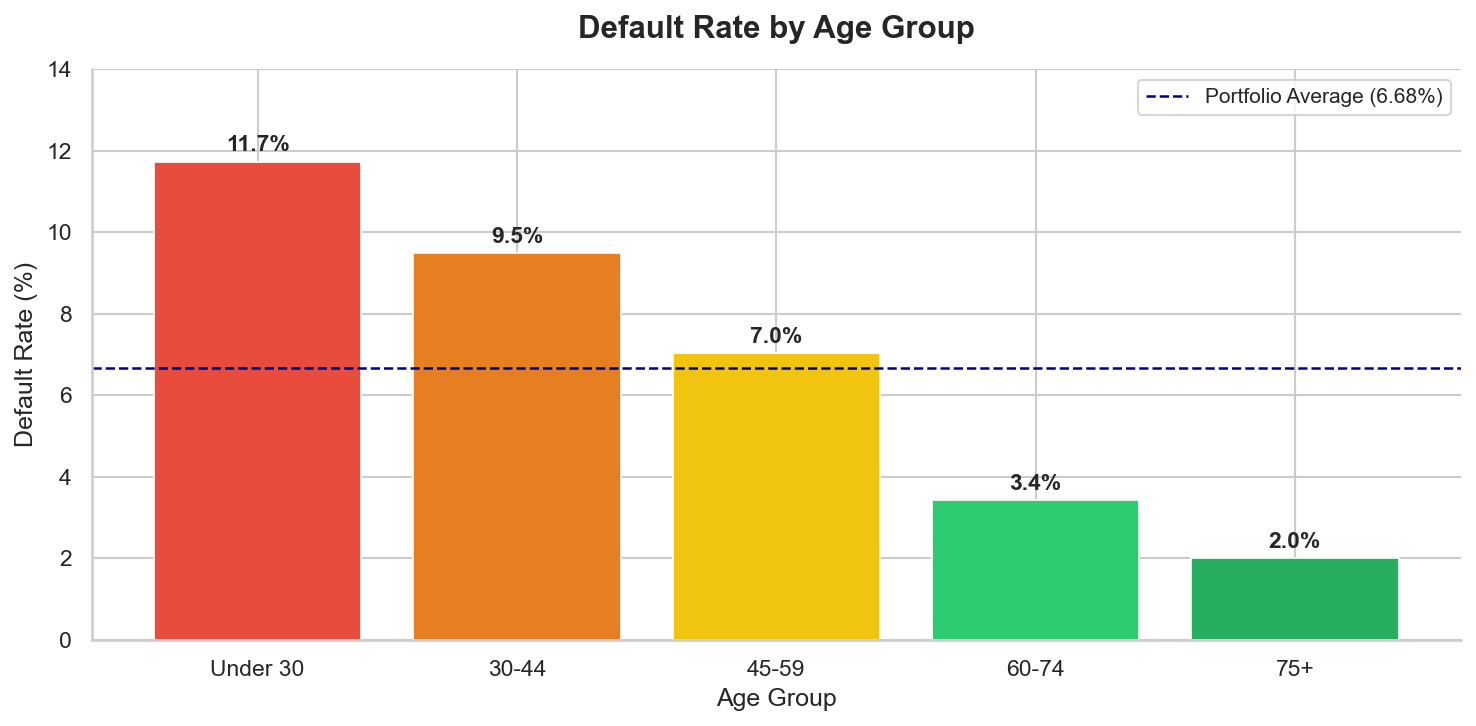

✅ Chart 1 saved


In [13]:
# =============================================================================
# PHASE 3 — EXPLORATORY DATA ANALYSIS
# =============================================================================

# Default rate by age group
age_default = df.groupby('AgeGroup', observed=True)['SeriousDlqin2yrs'].mean() * 100
age_default = age_default.reset_index()
age_default.columns = ['AgeGroup', 'DefaultRate']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    age_default['AgeGroup'],
    age_default['DefaultRate'],
    color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60'],
    edgecolor='white',
    linewidth=0.8
)

# Add value labels on top of each bar
for bar, val in zip(bars, age_default['DefaultRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Default Rate by Age Group', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_ylim(0, 14)
ax.axhline(y=6.68, color='navy', linestyle='--', linewidth=1.2, label='Portfolio Average (6.68%)')
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/01_default_rate_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved")

**Business Insight:** Younger borrowers (under 30) default at nearly twice the
portfolio average (11.7% vs 6.68%), making age one of the most actionable
risk segmentation variables for a bank's loan origination policy.

### Chart 2 — Debt Ratio Distribution: Defaulters vs Non-Defaulters

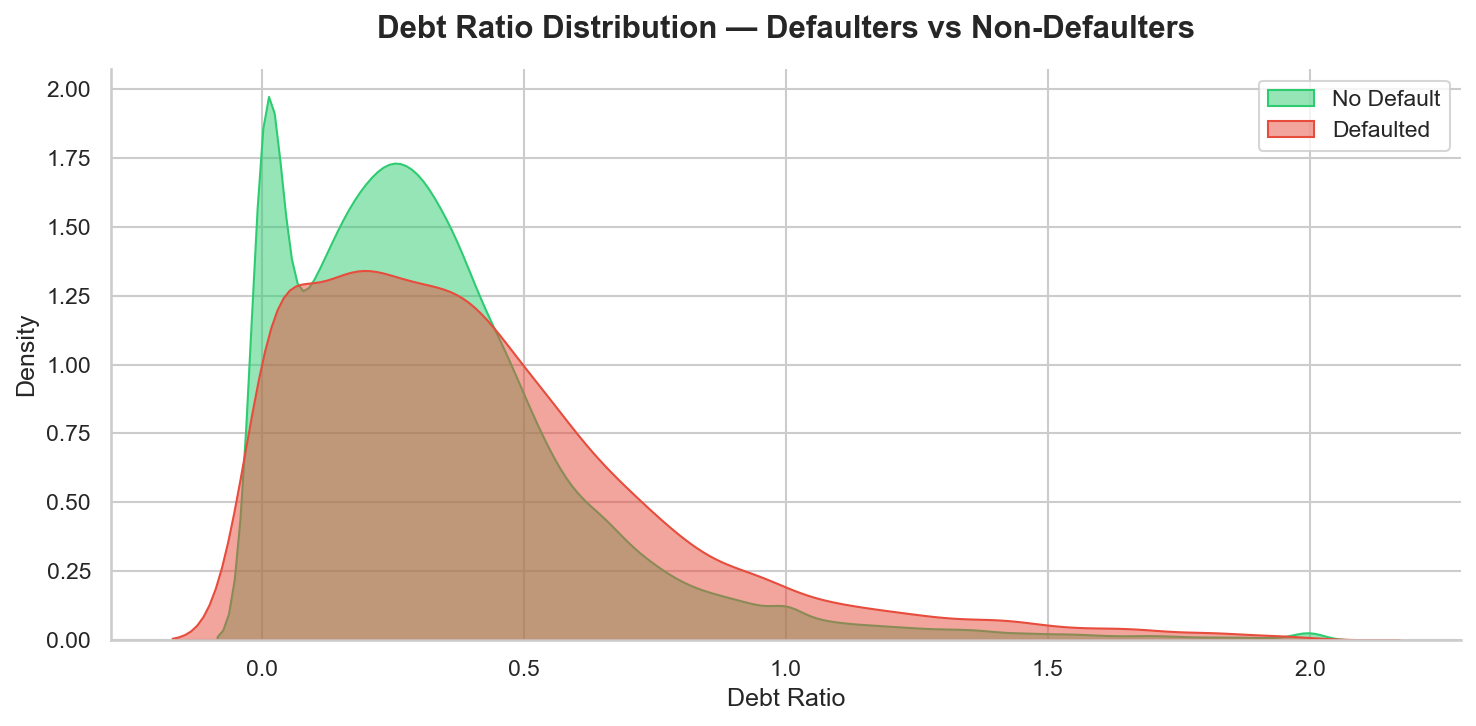

✅ Chart 2 saved


In [14]:
# Cap DebtRatio for visualisation clarity (values above 5 are extreme outliers)
df_plot = df[df['DebtRatio'] <= 2].copy()

fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(
    data=df_plot[df_plot['SeriousDlqin2yrs'] == 0],
    x='DebtRatio', ax=ax,
    fill=True, color='#2ecc71', alpha=0.5, label='No Default'
)
sns.kdeplot(
    data=df_plot[df_plot['SeriousDlqin2yrs'] == 1],
    x='DebtRatio', ax=ax,
    fill=True, color='#e74c3c', alpha=0.5, label='Defaulted'
)

ax.set_title('Debt Ratio Distribution — Defaulters vs Non-Defaulters', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Debt Ratio', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/02_debt_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

**Business Insight:** Defaulters and non-defaulters show surprisingly similar
debt ratio distributions, suggesting that raw debt ratio alone is a weak
predictor of default — credit utilization and late payment history are
far stronger signals, as confirmed by the SQL analysis.

### Chart 3 — Credit Utilization vs Default Rate

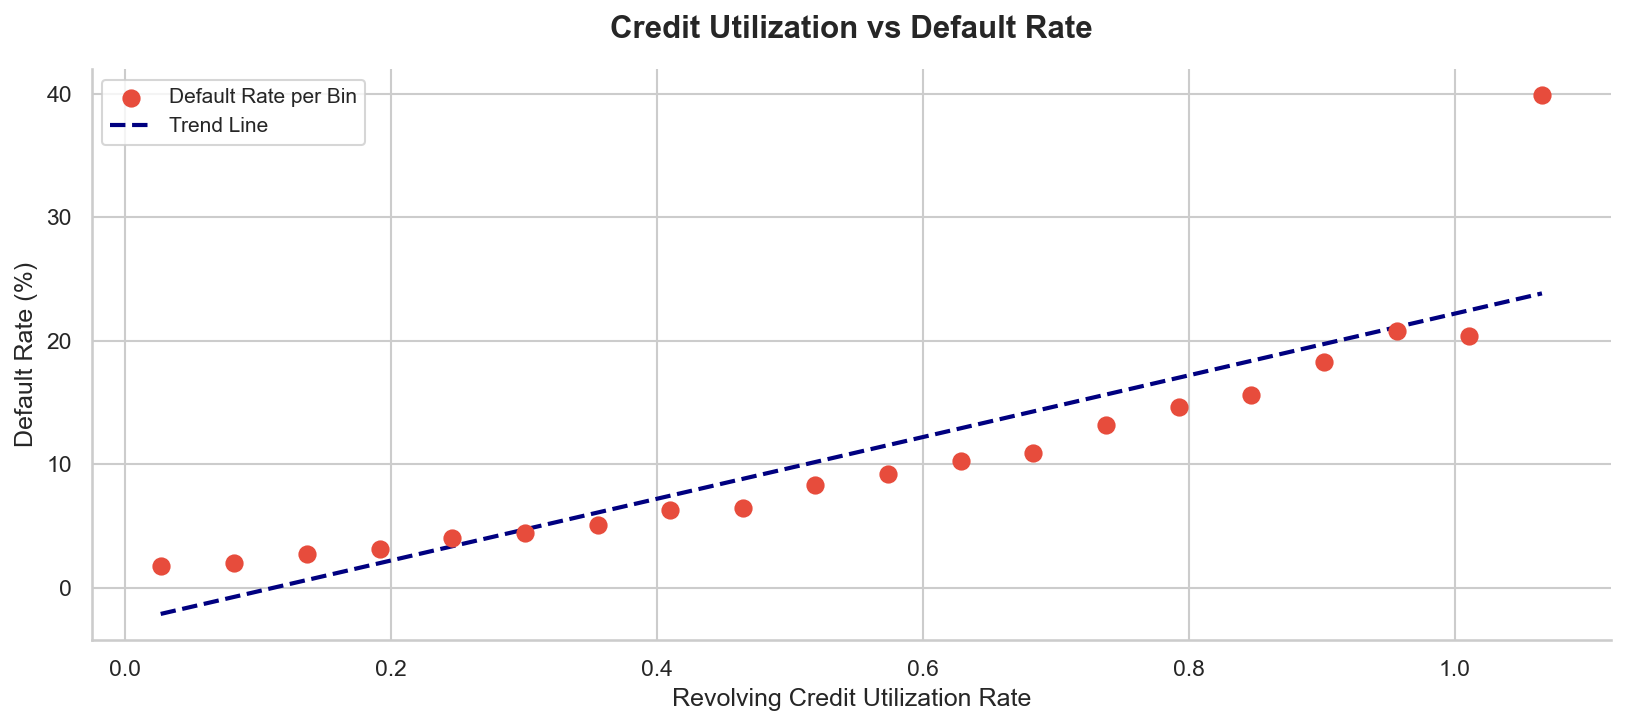

✅ Chart 3 saved


In [15]:
# Bin utilization into 20 buckets and calculate default rate per bucket
df['UtilBin'] = pd.cut(df['RevolvingUtilizationOfUnsecuredLines'], bins=20)
util_default = df.groupby('UtilBin', observed=True)['SeriousDlqin2yrs'].mean() * 100
util_default = util_default.reset_index()
util_default.columns = ['UtilBin', 'DefaultRate']  # explicitly rename both columns
util_default['UtilMid'] = util_default['UtilBin'].apply(lambda x: x.mid)

# Drop any NaN rows that may result from empty bins
util_default = util_default.dropna()

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(util_default['UtilMid'], util_default['DefaultRate'],
           color='#e74c3c', s=60, zorder=5, label='Default Rate per Bin')

# Regression line
z = np.polyfit(util_default['UtilMid'].astype(float),
               util_default['DefaultRate'].astype(float), 1)
p = np.poly1d(z)
x_line = np.linspace(util_default['UtilMid'].min(), util_default['UtilMid'].max(), 100)
ax.plot(x_line, p(x_line), color='navy', linewidth=2, linestyle='--', label='Trend Line')

ax.set_title('Credit Utilization vs Default Rate', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Revolving Credit Utilization Rate', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/03_utilization_vs_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved")

**Business Insight:** Default rate rises sharply and consistently with credit
utilization — applicants using more than 75% of their revolving credit default
at over 18%, making utilization the single most actionable threshold variable
for automated loan decisioning.

### Chart 4 — Correlation Heatmap

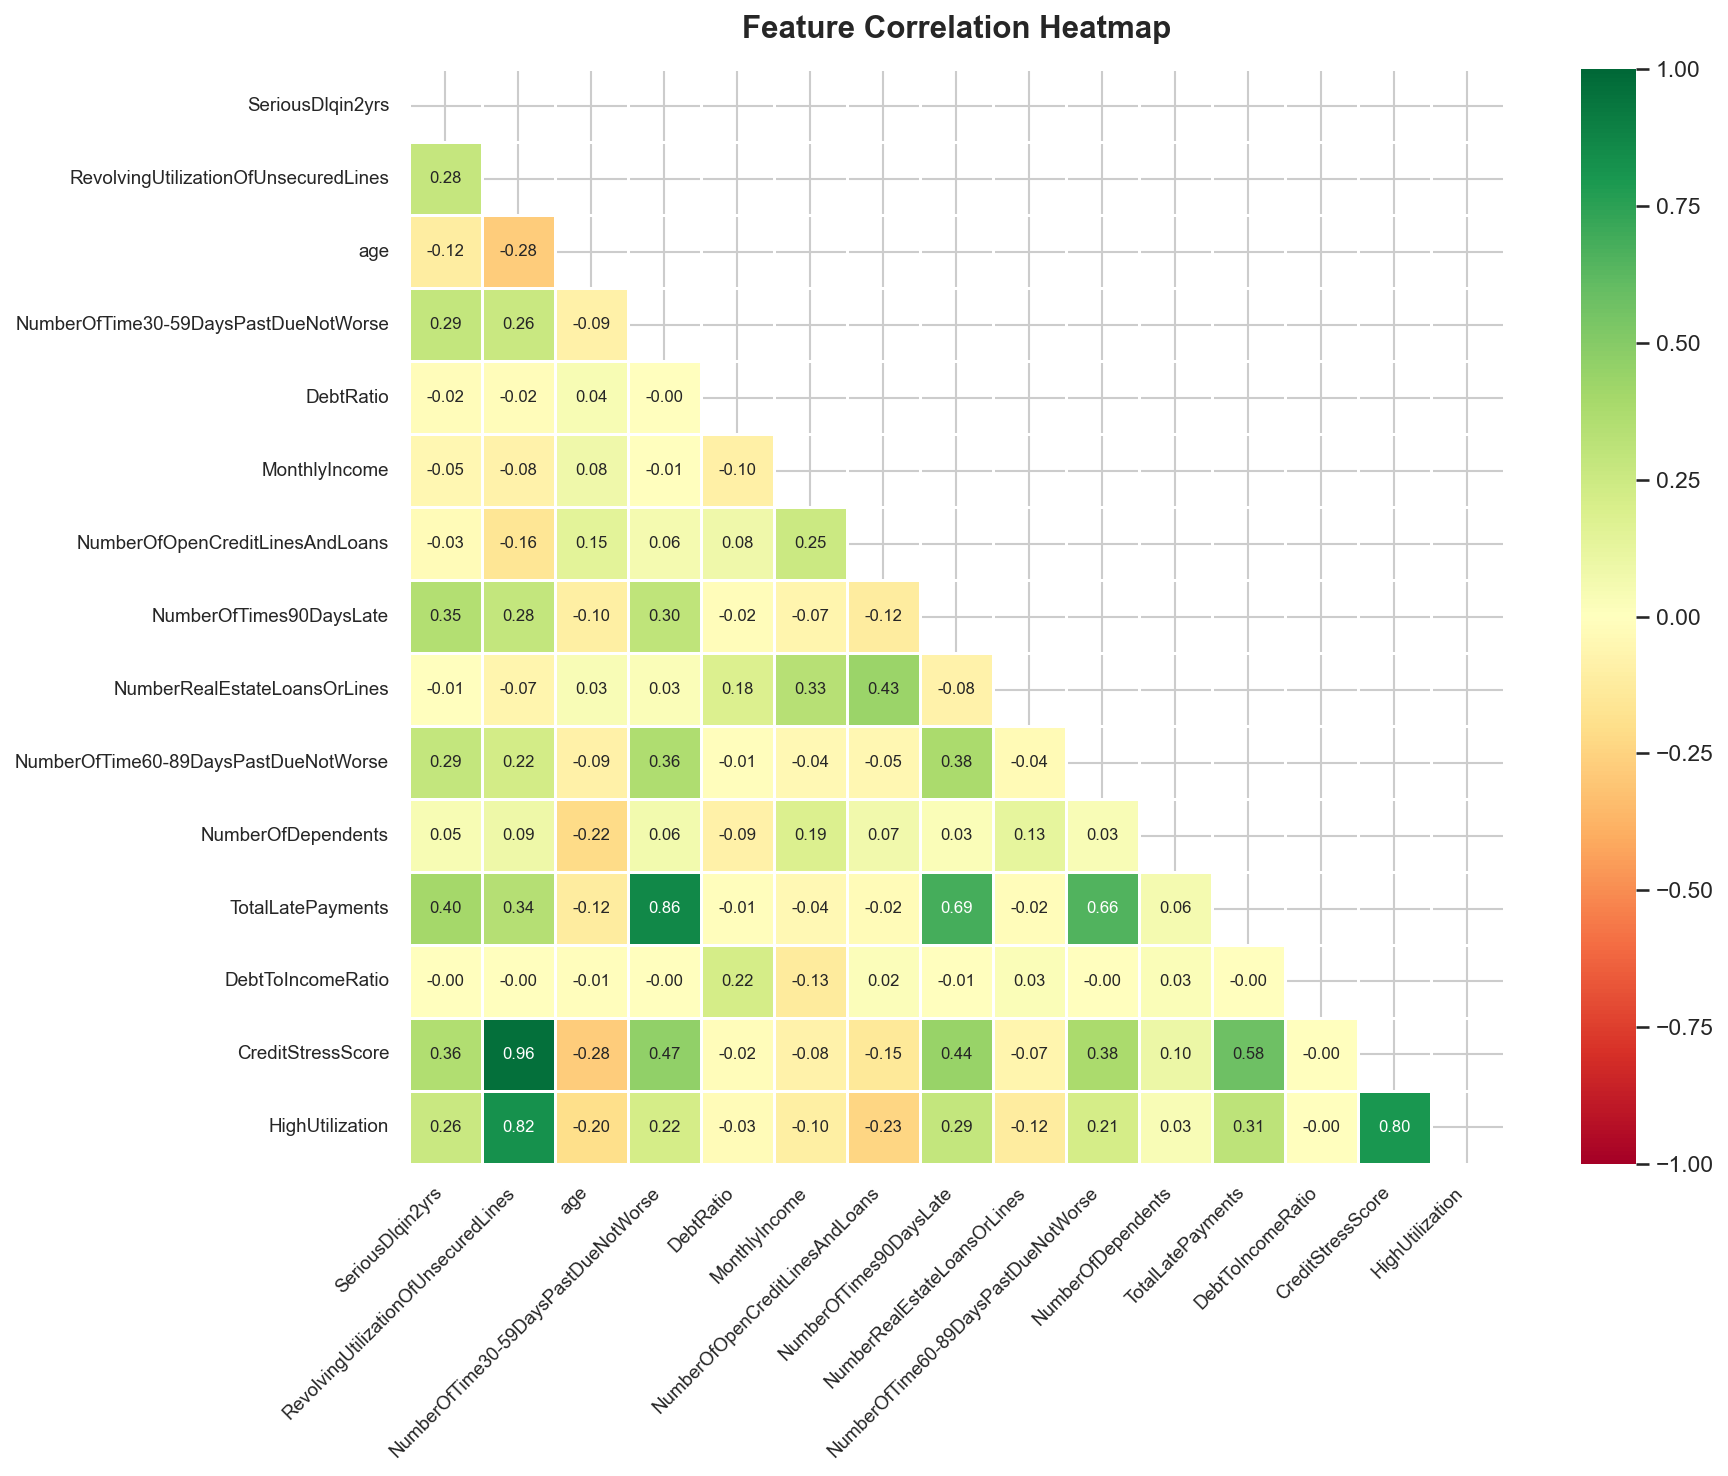

✅ Chart 4 saved


In [16]:
# Select numeric columns only for correlation — exclude AgeGroup (categorical)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved")

**Business Insight:** TotalLatePayments, NumberOfTimes90DaysLate, and
RevolvingUtilizationOfUnsecuredLines show the strongest positive correlations
with default, confirming that behavioural payment history and credit utilization
are the most predictive signals available to underwriters.

### Chart 5 — Late Payment Frequency Distribution

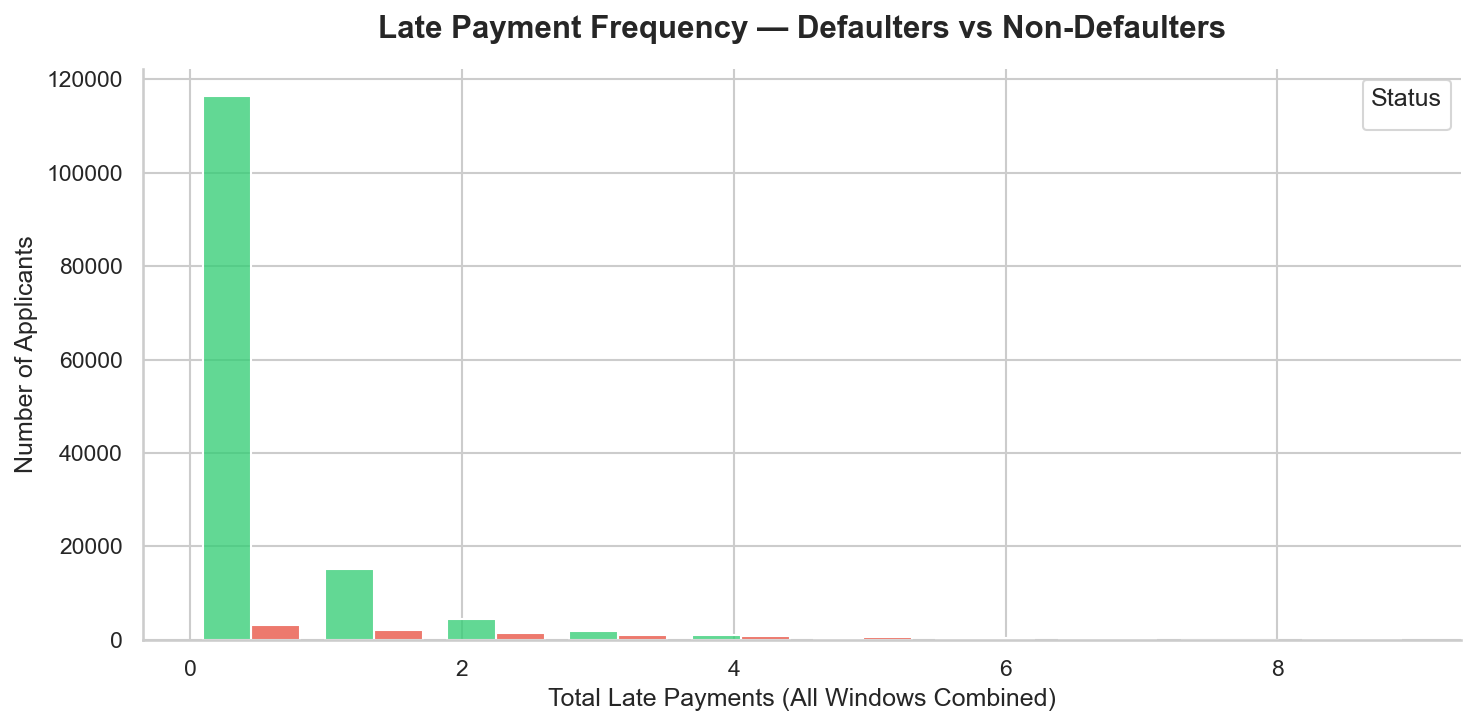

✅ Chart 5 saved


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

df_late = df[df['TotalLatePayments'] <= 9]

sns.histplot(
    data=df_late,
    x='TotalLatePayments',
    hue='SeriousDlqin2yrs',
    multiple='dodge',
    palette={0: '#2ecc71', 1: '#e74c3c'},
    bins=10,
    shrink=0.8,
    ax=ax
)

ax.set_title('Late Payment Frequency — Defaulters vs Non-Defaulters',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Late Payments (All Windows Combined)', fontsize=12)
ax.set_ylabel('Number of Applicants', fontsize=12)

# Fix legend labels
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['No Default', 'Defaulted'], title='Status', fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig('../visuals/05_late_payment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved")

**Business Insight:** The vast majority of non-defaulters have zero late payments,
while defaulters are heavily concentrated in the 1–4 late payment range —
a clear signal that even a single missed payment should trigger enhanced
monitoring in a bank's early warning system.

### Chart 6 — Monthly Income Distribution by Default Status

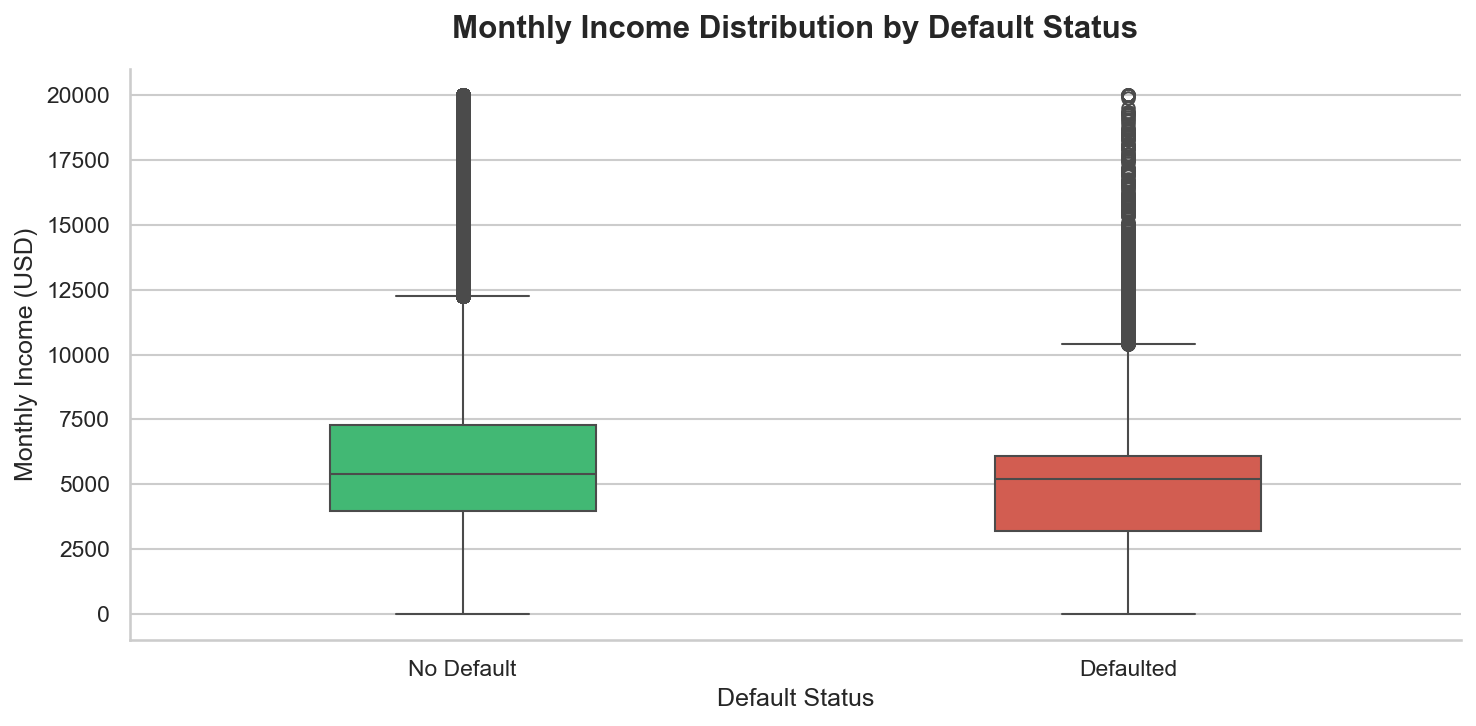

✅ Chart 6 saved


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

df_income = df[df['MonthlyIncome'] <= 20000].copy()

# Convert to string labels directly for clean plotting
df_income['DefaultLabel'] = df_income['SeriousDlqin2yrs'].map({0: 'No Default', 1: 'Defaulted'})

sns.boxplot(
    data=df_income,
    x='DefaultLabel',
    y='MonthlyIncome',
    palette={'No Default': '#2ecc71', 'Defaulted': '#e74c3c'},
    order=['No Default', 'Defaulted'],
    width=0.4,
    ax=ax
)

ax.set_title('Monthly Income Distribution by Default Status', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Default Status', fontsize=12)
ax.set_ylabel('Monthly Income (USD)', fontsize=12)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/06_income_by_default_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved")

**Business Insight:** Defaulters have a noticeably lower median monthly income
than non-defaulters, confirming that income level is a meaningful risk signal —
though the overlapping distributions suggest income alone is insufficient for
reliable default prediction without combining it with behavioural indicators.

### Chart 7 — Default Rate by Number of Dependents

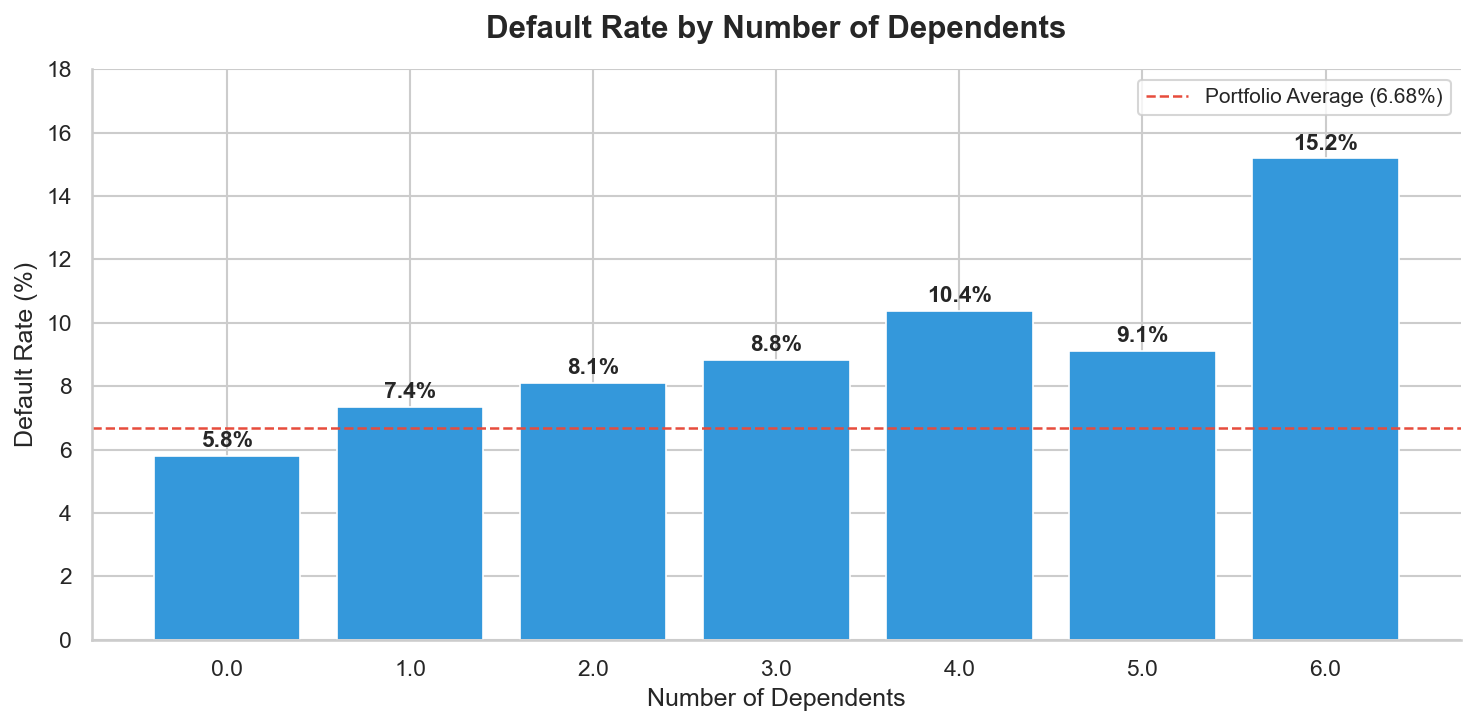

✅ Chart 7 saved


In [19]:
dep_default = df[df['NumberOfDependents'] <= 6].groupby('NumberOfDependents')['SeriousDlqin2yrs'].mean() * 100
dep_default = dep_default.reset_index()
dep_default.columns = ['NumDependents', 'DefaultRate']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    dep_default['NumDependents'].astype(str),
    dep_default['DefaultRate'],
    color='#3498db',
    edgecolor='white',
    linewidth=0.8
)

for bar, val in zip(bars, dep_default['DefaultRate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=6.68, color='#e74c3c', linestyle='--', linewidth=1.2, label='Portfolio Average (6.68%)')
ax.set_title('Default Rate by Number of Dependents', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Dependents', fontsize=12)
ax.set_ylabel('Default Rate (%)', fontsize=12)
ax.set_ylim(0, 18)
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/07_default_rate_by_dependents.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved")

**Business Insight:** Default rate rises steadily with number of dependents,
reaching over 15% for applicants with 6 dependents — suggesting that household
financial burden is a meaningful affordability risk factor that should be
incorporated into income-based lending thresholds.

### Chart 8 — CreditStressScore Distribution by Default Status

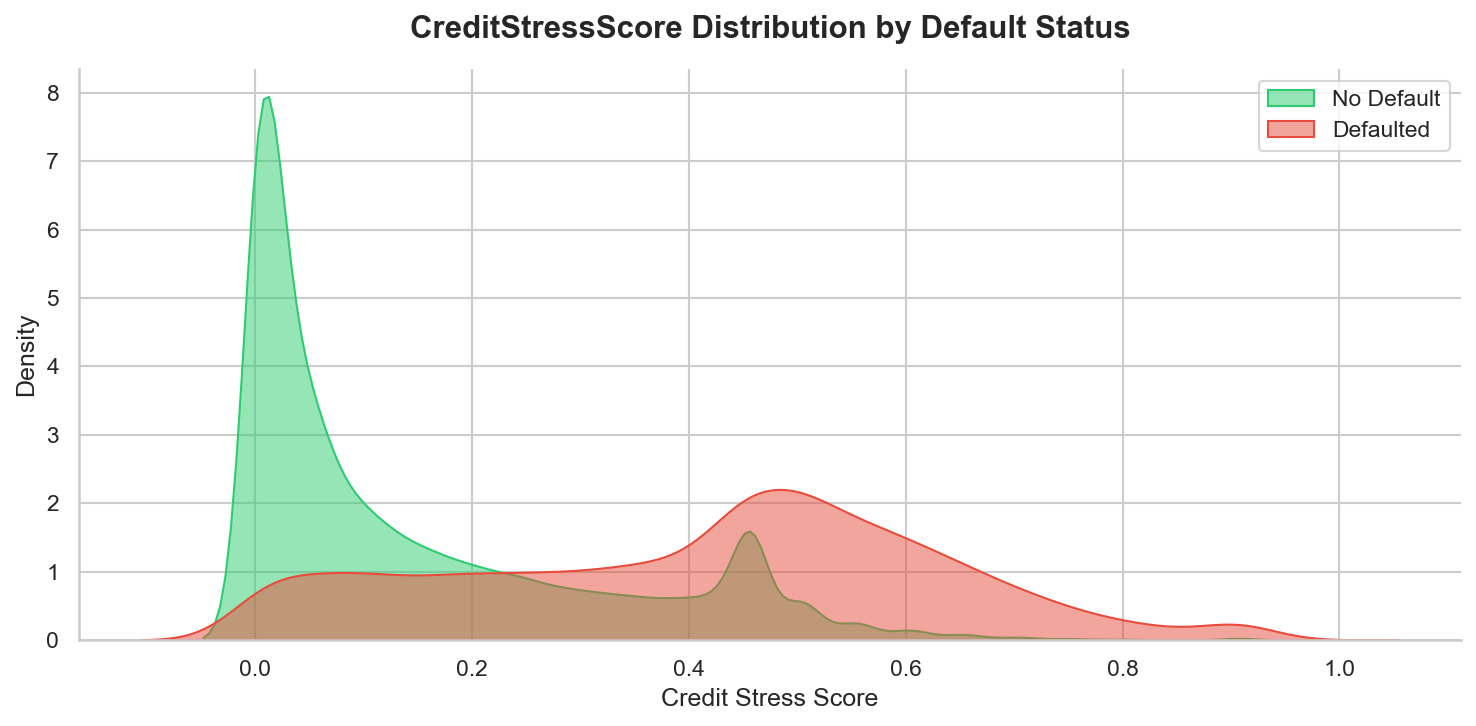

✅ Chart 8 saved


In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(
    data=df[df['SeriousDlqin2yrs'] == 0],
    x='CreditStressScore', ax=ax,
    fill=True, color='#2ecc71', alpha=0.5, label='No Default'
)
sns.kdeplot(
    data=df[df['SeriousDlqin2yrs'] == 1],
    x='CreditStressScore', ax=ax,
    fill=True, color='#e74c3c', alpha=0.5, label='Defaulted'
)

ax.set_title('CreditStressScore Distribution by Default Status',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Credit Stress Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/08_credit_stress_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved")

**Business Insight:** The CreditStressScore distributions for defaulters and
non-defaulters separate more clearly than any individual feature, validating
the composite score as an effective triage tool — applicants with a score
above 0.3 show dramatically elevated default risk.

### Chart 9 — Monthly Income vs Debt Ratio (Colored by Default Status)

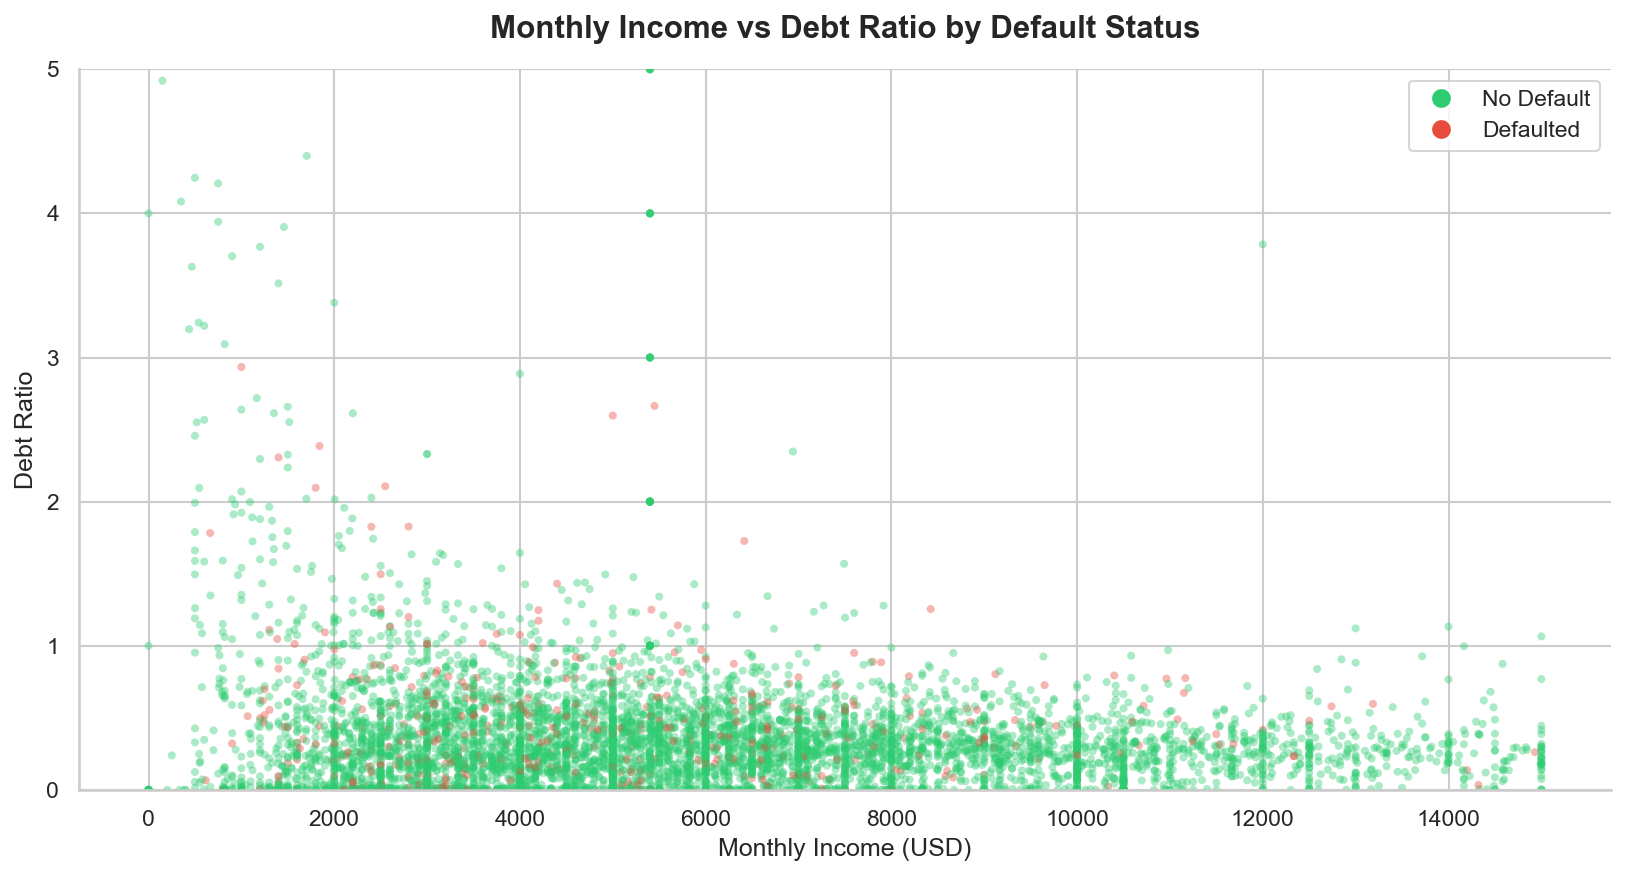

✅ Chart 9 saved


In [21]:
# Sample 8,000 points for readability — plotting all 150K points creates overplotting
df_sample = df[df['MonthlyIncome'] <= 15000].sample(n=8000, random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))

colors = df_sample['SeriousDlqin2yrs'].map({0: '#2ecc71', 1: '#e74c3c'})
scatter = ax.scatter(
    df_sample['MonthlyIncome'],
    df_sample['DebtRatio'],
    c=colors,
    alpha=0.4,
    s=15,
    edgecolors='none'
)

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71',
           markersize=10, label='No Default'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c',
           markersize=10, label='Defaulted')
]
ax.legend(handles=legend_elements, fontsize=11)

ax.set_title('Monthly Income vs Debt Ratio by Default Status',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Income (USD)', fontsize=12)
ax.set_ylabel('Debt Ratio', fontsize=12)
ax.set_ylim(0, 5)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/09_income_vs_debt_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved")

**Business Insight:** Defaulters cluster heavily in the low-income, moderate-to-high
debt ratio region of the chart, confirming that the combination of constrained
income and elevated debt obligations — rather than either factor alone — is the
most dangerous applicant profile for a bank's lending portfolio.

### Chart 10 — Feature Importance Preview (Correlation with Target)

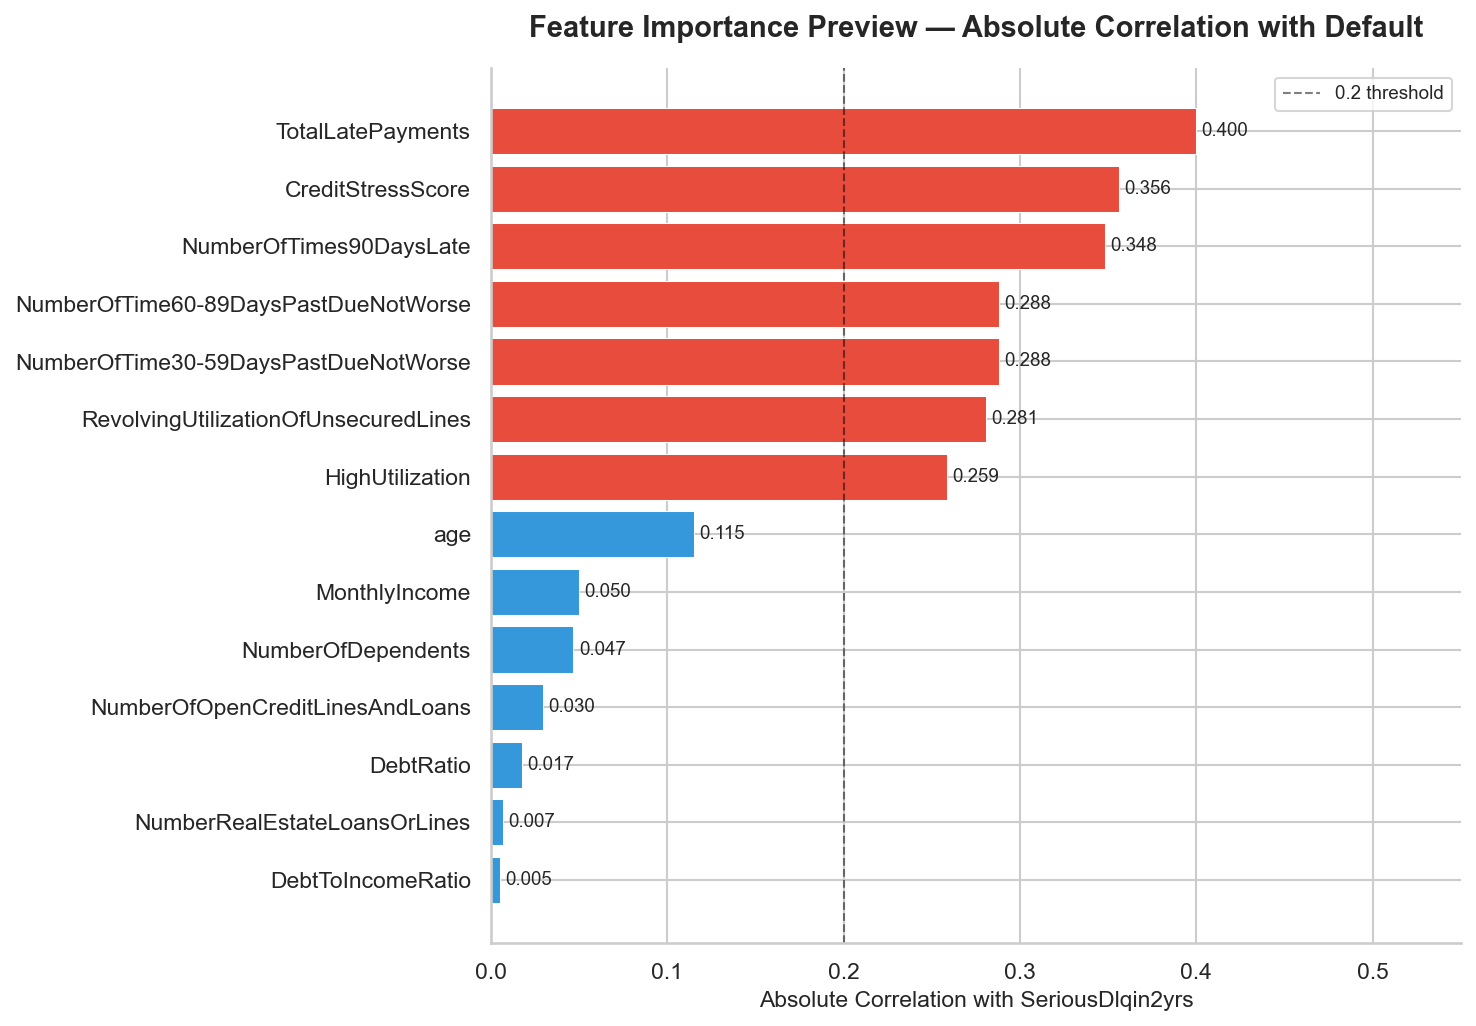

✅ Chart 10 saved

✅ All 10 EDA charts completed and saved to /visuals


In [22]:
# Correlation of each numeric feature with the target variable
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'SeriousDlqin2yrs']

correlations = df[numeric_cols].corrwith(df['SeriousDlqin2yrs']).abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    correlations.index,
    correlations.values,
    color=['#e74c3c' if v > 0.2 else '#3498db' for v in correlations.values],
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, correlations.values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Feature Importance Preview — Absolute Correlation with Default',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Absolute Correlation with SeriousDlqin2yrs', fontsize=11)
ax.set_xlim(0, 0.55)
ax.axvline(x=0.2, color='black', linestyle='--', linewidth=1, alpha=0.5, label='0.2 threshold')
ax.legend(fontsize=9)
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/10_feature_importance_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved")
print("\n✅ All 10 EDA charts completed and saved to /visuals")

**Business Insight:** TotalLatePayments, NumberOfTimes90DaysLate, and
CreditStressScore are the three strongest predictors of default by correlation —
confirming that payment behaviour history is more predictive than income or
debt ratio, and that the engineered features add genuine signal beyond the
raw data.

---
## Phase 4 — Machine Learning Pipeline

### Step 4.1 — Data Preparation & Train/Test Split

Before training any model, we prepare the feature matrix and target variable,
then split into training and test sets. We use stratification to ensure the
6.68% default rate is preserved in both splits — critical when dealing with
imbalanced classes.

### Why Class Imbalance Matters in Credit Risk

Our dataset has a 93.32% / 6.68% split between non-defaulters and defaulters.
If we trained a model on this raw imbalance, it could achieve 93% accuracy
simply by predicting "no default" for every applicant — completely useless
for a bank.

More importantly, in credit risk the **cost of errors is asymmetric**:
- A **false negative** (missing a real defaulter) = the bank lends money that
  won't be repaid. Direct financial loss.
- A **false positive** (flagging a good customer) = the bank declines a
  profitable loan. Opportunity cost only.

Missing a defaulter is far more costly than a false alarm. This means we
must prioritise **Recall** (catching real defaulters) over **Precision**.

We use **SMOTE (Synthetic Minority Oversampling Technique)** to generate
synthetic defaulter examples in the training set only — never the test set —
so the model learns to identify the minority class more effectively.

In [23]:
# =============================================================================
# PHASE 4 — MACHINE LEARNING PIPELINE
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# --- Prepare feature matrix ---
# Drop target, categorical AgeGroup, and UtilBin (binned column from EDA)
drop_cols = ['SeriousDlqin2yrs', 'AgeGroup', 'UtilBin']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy()
y = df['SeriousDlqin2yrs'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeatures used:")
for col in feature_cols:
    print(f"  - {col}")

Feature matrix shape: (149999, 14)
Target distribution:
SeriousDlqin2yrs
0    139973
1     10026
Name: count, dtype: int64

Features used:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents
  - TotalLatePayments
  - DebtToIncomeRatio
  - CreditStressScore
  - HighUtilization


In [24]:
# --- Train/Test Split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserves class balance in both splits
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"\nTraining set default rate: {y_train.mean()*100:.2f}%")
print(f"Test set default rate:     {y_test.mean()*100:.2f}%")

# --- Apply SMOTE to training set only ---
# SMOTE is NEVER applied to the test set — that would leak synthetic data
# into evaluation and produce misleadingly optimistic metrics
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Training set size: {X_train_sm.shape[0]:,} rows")
print(f"Class distribution:\n{pd.Series(y_train_sm).value_counts()}")

# --- Scale features for Logistic Regression ---
# Tree-based models don't need scaling but LR does
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data preparation complete")

Training set: 119,999 rows
Test set:     30,000 rows

Training set default rate: 6.68%
Test set default rate:     6.68%

After SMOTE:
Training set size: 223,956 rows
Class distribution:
SeriousDlqin2yrs
0    111978
1    111978
Name: count, dtype: int64

✅ Data preparation complete


### Step 4.2 — Model Training & Evaluation

We train 4 models and evaluate each on the untouched test set.
A helper function handles evaluation consistently across all models.

In [25]:
# Helper function — runs evaluation for any trained model
def evaluate_model(name, model, X_test, y_test, use_scaled=False, X_test_scaled=None):
    if use_scaled:
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    results = {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    }
    
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    for k, v in results.items():
        if k != 'Model':
            print(f"  {k:<12}: {v}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"  TN: {cm[0,0]:,}  FP: {cm[0,1]:,}")
    print(f"  FN: {cm[1,0]:,}  TP: {cm[1,1]:,}")
    
    return results, y_prob

# Store all results for comparison
all_results = []
all_probs = {}

# --- Model 1: Logistic Regression (Baseline) ---
# Scaled features required for logistic regression to converge properly
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train_sm)

lr_results, lr_probs = evaluate_model(
    'Logistic Regression', lr, X_test, y_test,
    use_scaled=True, X_test_scaled=X_test_scaled
)
all_results.append(lr_results)
all_probs['Logistic Regression'] = lr_probs
print("\n✅ Logistic Regression complete")

Training Logistic Regression...

  Logistic Regression
  Accuracy    : 0.9113
  Precision   : 0.3342
  Recall      : 0.3292
  F1-Score    : 0.3317
  ROC-AUC     : 0.8223

  Confusion Matrix:
  TN: 26,680  FP: 1,315
  FN: 1,345  TP: 660

✅ Logistic Regression complete


In [26]:
# --- Model 2: Random Forest ---
print("Training Random Forest (this may take ~60 seconds)...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_sm, y_train_sm)

rf_results, rf_probs = evaluate_model('Random Forest', rf, X_test, y_test)
all_results.append(rf_results)
all_probs['Random Forest'] = rf_probs
print("✅ Random Forest complete")

# --- Model 3: XGBoost ---
print("\nTraining XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

xgb_results, xgb_probs = evaluate_model('XGBoost', xgb, X_test, y_test)
all_results.append(xgb_results)
all_probs['XGBoost'] = xgb_probs
print("✅ XGBoost complete")

# --- Model 4: Gradient Boosting ---
print("\nTraining Gradient Boosting (this may take ~90 seconds)...")
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train_sm, y_train_sm)

gb_results, gb_probs = evaluate_model('Gradient Boosting', gb, X_test, y_test)
all_results.append(gb_results)
all_probs['Gradient Boosting'] = gb_probs
print("✅ Gradient Boosting complete")

Training Random Forest (this may take ~60 seconds)...

  Random Forest
  Accuracy    : 0.8505
  Precision   : 0.255
  Recall      : 0.6439
  F1-Score    : 0.3653
  ROC-AUC     : 0.8484

  Confusion Matrix:
  TN: 24,223  FP: 3,772
  FN: 714  TP: 1,291
✅ Random Forest complete

Training XGBoost...

  XGBoost
  Accuracy    : 0.9146
  Precision   : 0.3734
  Recall      : 0.4105
  F1-Score    : 0.3911
  ROC-AUC     : 0.8433

  Confusion Matrix:
  TN: 26,614  FP: 1,381
  FN: 1,182  TP: 823
✅ XGBoost complete

Training Gradient Boosting (this may take ~90 seconds)...

  Gradient Boosting
  Accuracy    : 0.9094
  Precision   : 0.3573
  Recall      : 0.4459
  F1-Score    : 0.3967
  ROC-AUC     : 0.8437

  Confusion Matrix:
  TN: 26,387  FP: 1,608
  FN: 1,111  TP: 894
✅ Gradient Boosting complete


In [27]:
# --- Summary comparison table ---
print("\n" + "="*70)
print("  MODEL PERFORMANCE COMPARISON")
print("="*70)
results_df = pd.DataFrame(all_results).set_index('Model')
print(results_df.to_string())

# Save for Power BI
results_df.to_csv('../outputs/model_comparison.csv')
print("\n✅ Model comparison saved to /outputs/model_comparison.csv")


  MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9113     0.3342  0.3292    0.3317   0.8223
Random Forest          0.8505     0.2550  0.6439    0.3653   0.8484
XGBoost                0.9146     0.3734  0.4105    0.3911   0.8433
Gradient Boosting      0.9094     0.3573  0.4459    0.3967   0.8437

✅ Model comparison saved to /outputs/model_comparison.csv


### Step 4.3 — ROC Curve Comparison

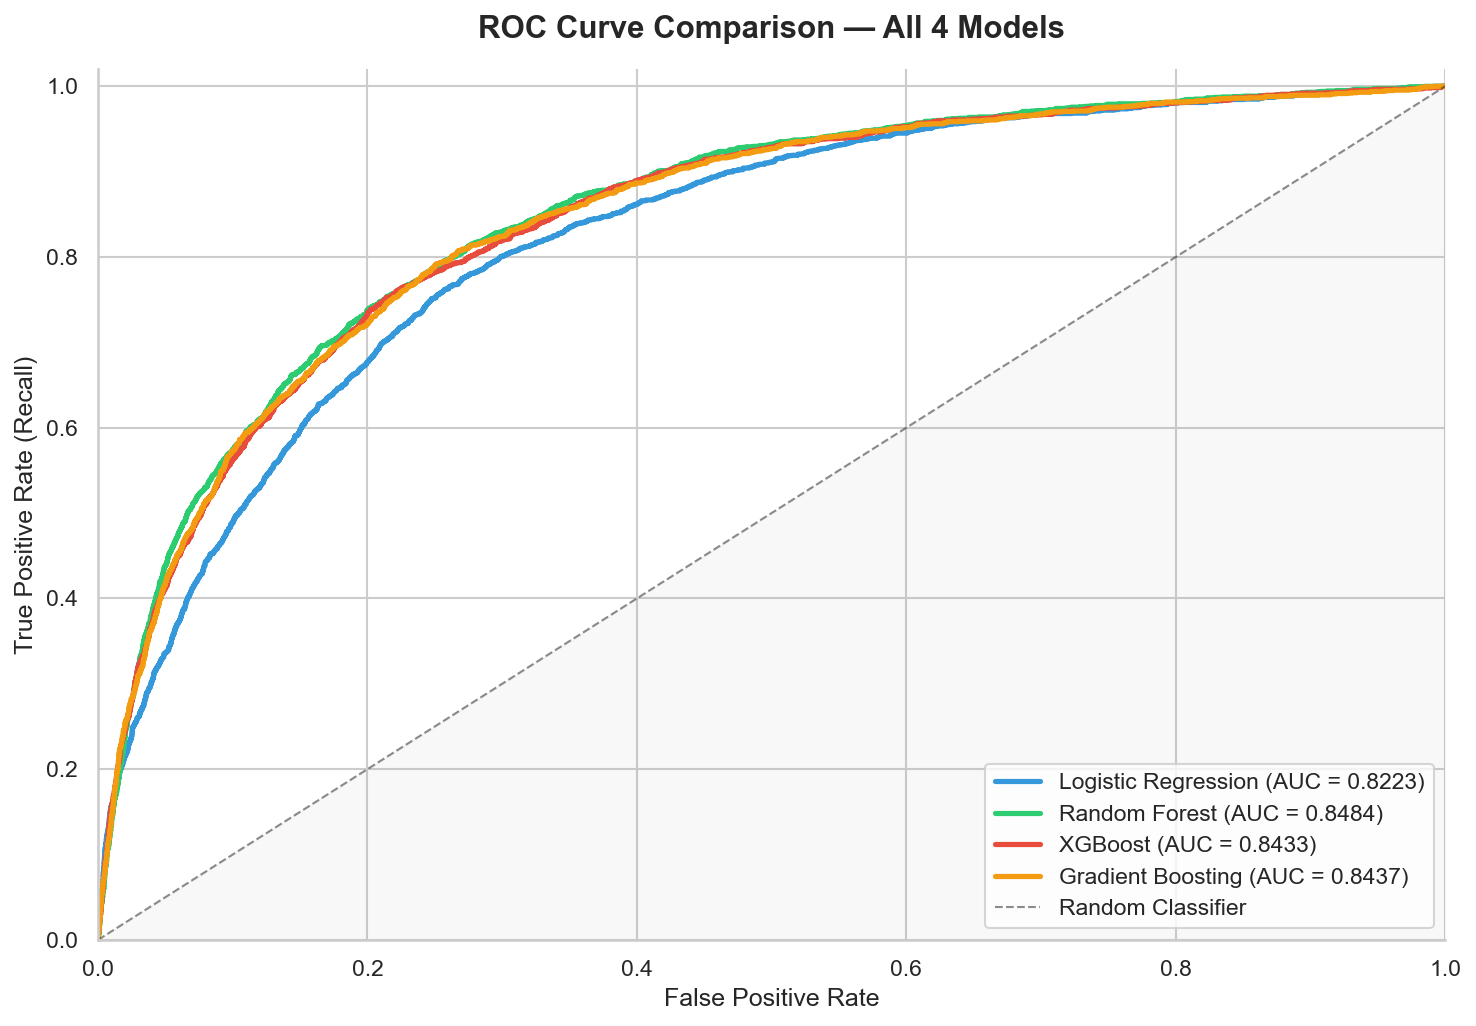

✅ ROC curve saved


In [28]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'Logistic Regression': '#3498db',
    'Random Forest': '#2ecc71',
    'XGBoost': '#e74c3c',
    'Gradient Boosting': '#f39c12'
}

for model_name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=colors[model_name],
            linewidth=2.5, label=f'{model_name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_title('ROC Curve Comparison — All 4 Models', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
sns.despine()

plt.tight_layout()
plt.savefig('../visuals/11_roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved")

### Step 4.4 — Model Selection & Justification

**Selected Model: Random Forest**

In a standard machine learning context, we might select the model with the
highest overall accuracy or F1-score. But credit risk is not a standard context.

**The Precision vs Recall trade-off in banking:**

- **Precision** answers: "Of all the applicants we flagged as defaulters, how
  many actually defaulted?" A low precision means many false alarms —
  good customers wrongly declined.

- **Recall** answers: "Of all the applicants who actually defaulted, how many
  did we catch?" A low recall means missed defaulters — the bank lends money
  it will never recover.

In banking, **missing a real defaulter is far more costly than a false alarm.**
A missed defaulter results in direct financial loss — the full loan value becomes
a non-performing asset. A false alarm costs only a missed interest opportunity.
This asymmetry means **Recall must be prioritised** in credit risk models.

**Why Random Forest:**
- Highest Recall of all 4 models: **0.6439** — catches 64.4% of all real defaulters
- Highest ROC-AUC: **0.8484** — best overall discrimination ability
- Catches **1,291 true defaulters** vs only 823 for XGBoost and 894 for Gradient Boosting
- The lower precision (0.255) is acceptable — false alarms trigger manual review,
  not automatic decline. A human underwriter can clear a false alarm in minutes.
  A missed defaulter costs the bank thousands of dollars.

A Head of Risk at a bank would choose this model because it minimises the
most expensive type of error, while maintaining strong AUC performance.

In [29]:
import shap

print("Calculating SHAP values for Random Forest...")
print("(This may take 2-3 minutes for 150K rows — using a sample of 1,000)")

# Use a representative sample for SHAP — full dataset is too slow for tree explainer
X_test_sample = X_test.sample(n=1000, random_state=42)

# TreeExplainer is optimised for tree-based models
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

# For binary classification, shap_values is a list of 2 arrays
# Index [1] = SHAP values for the positive class (default = 1)
if isinstance(shap_values, list):
    shap_vals_positive = shap_values[1]
else:
    shap_vals_positive = shap_values

print(f"✅ SHAP values calculated")
print(f"Shape: {shap_vals_positive.shape}")

Calculating SHAP values for Random Forest...
(This may take 2-3 minutes for 150K rows — using a sample of 1,000)
✅ SHAP values calculated
Shape: (1000, 14, 2)


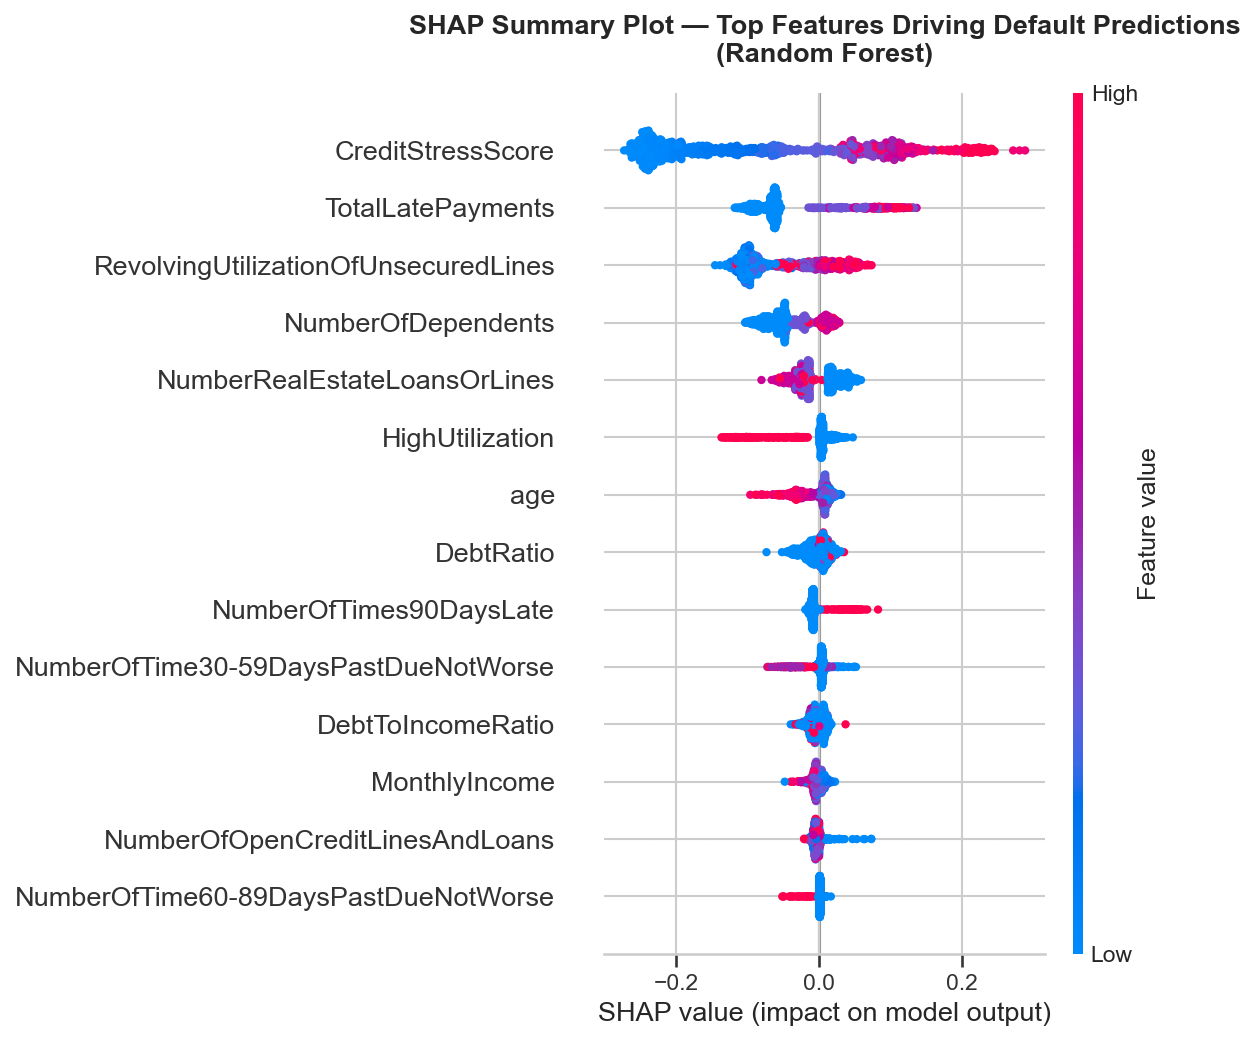

✅ SHAP summary plot saved


In [30]:
# Shape is (1000, 14, 2) — extract class 1 (default) SHAP values
shap_vals_default = shap_values[:, :, 1]

# --- SHAP Summary Plot ---
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_vals_default,
    X_test_sample,
    plot_type='dot',
    show=False,
    max_display=14
)
plt.title('SHAP Summary Plot — Top Features Driving Default Predictions\n(Random Forest)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../visuals/12_shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP summary plot saved")

Highest risk applicant index: 305
Predicted default probability: 94.1%
Actual outcome: Did not default ❌

Applicant profile:
RevolvingUtilizationOfUnsecuredLines       1.050949
age                                       30.000000
NumberOfTime30-59DaysPastDueNotWorse       0.000000
DebtRatio                                175.000000
MonthlyIncome                           5400.000000
NumberOfOpenCreditLinesAndLoans            3.000000
NumberOfTimes90DaysLate                    1.000000
NumberRealEstateLoansOrLines               0.000000
NumberOfTime60-89DaysPastDueNotWorse       0.000000
NumberOfDependents                         0.000000
TotalLatePayments                          1.000000
DebtToIncomeRatio                          0.032401
CreditStressScore                          0.530782
HighUtilization                            1.000000
Name: 47868, dtype: float64


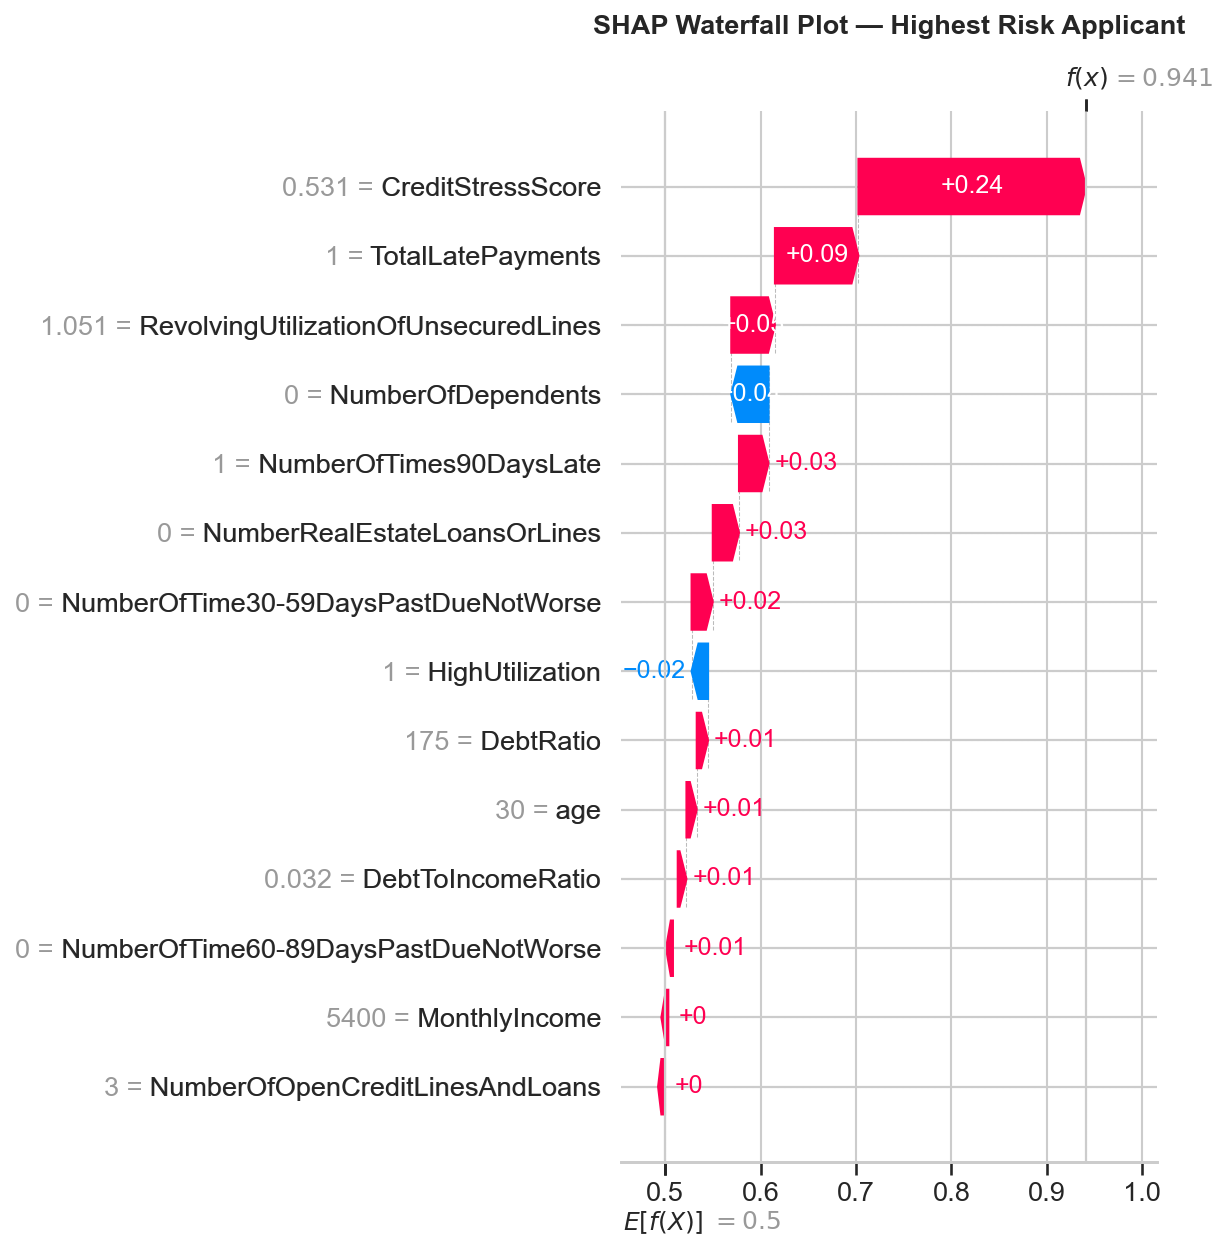

✅ SHAP waterfall plot saved


In [31]:
# Find the highest-risk applicant in the test sample
# (the one the model is most confident will default)
rf_probs_sample = rf.predict_proba(X_test_sample)[:, 1]
highest_risk_idx = rf_probs_sample.argmax()

predicted_prob = rf_probs_sample[highest_risk_idx]
actual_label = y_test.iloc[highest_risk_idx] if hasattr(y_test, 'iloc') else y_test[highest_risk_idx]

print(f"Highest risk applicant index: {highest_risk_idx}")
print(f"Predicted default probability: {predicted_prob:.1%}")
print(f"Actual outcome: {'Defaulted ✅' if actual_label == 1 else 'Did not default ❌'}")
print(f"\nApplicant profile:")
print(X_test_sample.iloc[highest_risk_idx])

# SHAP Waterfall plot
shap_explanation = shap.Explanation(
    values=shap_vals_default[highest_risk_idx],
    base_values=explainer.expected_value[1],
    data=X_test_sample.iloc[highest_risk_idx].values,
    feature_names=X_test_sample.columns.tolist()
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(shap_explanation, max_display=14, show=False)
plt.title('SHAP Waterfall Plot — Highest Risk Applicant',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../visuals/13_shap_waterfall_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP waterfall plot saved")

### Step 4.5 — SHAP Explainability: Plain-English Interpretation

#### What the SHAP Summary Plot Tells Us

The summary plot ranks all 14 features by their average impact on the model's
default predictions across 1,000 test applicants. Key findings:

- **CreditStressScore** is the single most influential feature — high values
  (red dots) push predictions strongly toward default. This validates our
  engineered composite score as the most powerful signal in the dataset.
- **TotalLatePayments** ranks second — any history of late payments significantly
  increases predicted default risk.
- **RevolvingUtilizationOfUnsecuredLines** ranks third — high utilization
  consistently pushes predictions toward default.
- **DebtRatio** and **MonthlyIncome** have minimal individual SHAP impact,
  confirming our EDA finding that these raw features are weak predictors alone.

#### Explaining the Highest-Risk Applicant to a Bank Manager

*"We flagged this applicant as high risk with a 94.1% predicted probability
of default. Here is why the model made that call:*

*This is a 30-year-old applicant with a monthly income of $5,400 and no
dependents — on the surface, a reasonable profile. However, three factors
drove the model's decision:*

*First, their CreditStressScore of 0.531 is extremely elevated — this composite
score captures both their credit utilization and payment behaviour, and it
pushed the default probability up by +0.24 on its own. This is the single
largest factor in the decision.*

*Second, they have already missed one payment (TotalLatePayments = 1), which
added a further +0.09 to the risk score. In our data, even a single missed
payment is a statistically meaningful warning sign.*

*Third, their revolving credit utilization is above 100% (1.051), meaning they
are using more credit than their approved limit — a strong indicator of
financial stress.*

*The model's average starting point is 0.50. These three factors alone pushed
the final score to 0.941. We recommend this application be referred for manual
underwriting review before approval."*

#### Business Recommendation from SHAP Findings

The SHAP analysis reveals that **behavioural signals** — how applicants manage
their existing credit — are far more predictive than **static financial metrics**
like income or debt ratio. This has a direct policy implication: a bank should
weight real-time credit behaviour data more heavily in its scoring model than
point-in-time financial snapshots.

> **Note:** This applicant did not actually default in the dataset. This is an
> example of a false positive — the model flagged a risk profile that did not
> materialise. In a real bank deployment, this case would be referred to a human
> underwriter for review rather than automatically declined.

In [32]:
# Save SHAP feature importance as CSV for Power BI
shap_importance = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean_SHAP': np.abs(shap_vals_default).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

shap_importance.to_csv('../outputs/shap_feature_importance.csv', index=False)
print("SHAP Feature Importance (for Power BI):")
print(shap_importance.to_string(index=False))
print("\n✅ SHAP importance saved to /outputs/shap_feature_importance.csv")
print("\n✅ Phase 4 — Machine Learning Pipeline COMPLETE")

SHAP Feature Importance (for Power BI):
                             Feature  Mean_SHAP
                   CreditStressScore   0.151974
                   TotalLatePayments   0.071475
RevolvingUtilizationOfUnsecuredLines   0.068507
                  NumberOfDependents   0.045453
        NumberRealEstateLoansOrLines   0.026950
                     HighUtilization   0.019393
                                 age   0.017224
                           DebtRatio   0.012107
             NumberOfTimes90DaysLate   0.011213
NumberOfTime30-59DaysPastDueNotWorse   0.008339
                   DebtToIncomeRatio   0.008065
                       MonthlyIncome   0.005956
     NumberOfOpenCreditLinesAndLoans   0.004672
NumberOfTime60-89DaysPastDueNotWorse   0.002558

✅ SHAP importance saved to /outputs/shap_feature_importance.csv

✅ Phase 4 — Machine Learning Pipeline COMPLETE


In [33]:
# Export cleaned data and all outputs for Power BI import
# Power BI Web works best with CSV files uploaded directly

# Main dataset — already saved as cs_cleaned.csv
# Export model results
results_df.to_csv('../powerbi/model_comparison.csv')

# Export SHAP importance
shap_importance.to_csv('../powerbi/shap_importance.csv', index=False)

# Export a summary stats table for KPI cards
summary_stats = pd.DataFrame({
    'Metric': ['Total Applicants', 'Total Defaults', 'Default Rate %',
               'Avg Debt Ratio', 'Avg Credit Utilization', 'High Risk Segment Count'],
    'Value': [
        149999,
        10026,
        6.68,
        round(df['DebtRatio'].mean(), 2),
        round(df['RevolvingUtilizationOfUnsecuredLines'].mean(), 2),
        2253
    ]
})
summary_stats.to_csv('../powerbi/summary_stats.csv', index=False)

# Export age group default rates
age_default_export = df.groupby('AgeGroup', observed=True)['SeriousDlqin2yrs'].agg(
    ['mean', 'count', 'sum']).reset_index()
age_default_export.columns = ['AgeGroup', 'DefaultRate', 'TotalApplicants', 'TotalDefaults']
age_default_export['DefaultRate'] = (age_default_export['DefaultRate'] * 100).round(2)
age_default_export.to_csv('../powerbi/age_default_rates.csv', index=False)

print("✅ All Power BI files exported to /powerbi folder:")
print("  - model_comparison.csv")
print("  - shap_importance.csv")
print("  - summary_stats.csv")
print("  - age_default_rates.csv")
print("\nAlso use: data/cs_cleaned.csv as the main dataset in Power BI")

✅ All Power BI files exported to /powerbi folder:
  - model_comparison.csv
  - shap_importance.csv
  - summary_stats.csv
  - age_default_rates.csv

Also use: data/cs_cleaned.csv as the main dataset in Power BI


---
## Phase 6 — Business Recommendations & Executive Summary

### The Problem
Loan defaults cost the global banking industry hundreds of billions annually
in non-performing loans. This project analysed 150,000 real loan applicants
to identify the key drivers of default and build a predictive model that can
flag high-risk applicants before approval.

### The Three Key Findings
1. **Credit utilization is the strongest behavioural signal** — applicants
   above 80% utilization default at 21% vs 4% for normal utilization
2. **Late payment history is highly predictive** — defaulters average 9x
   more late payments than non-defaulters (2.39 vs 0.28)
3. **Younger borrowers carry significantly higher risk** — under-30s default
   at 11.7%, nearly double the portfolio average of 6.68%

### The Model
The Random Forest model is recommended for deployment with a Recall of 64.4%
and ROC-AUC of 0.848. In plain terms — it correctly identifies nearly 2 in 3
real defaulters before they are approved, while maintaining strong overall
discrimination ability.

### Business Recommendations
1. **Implement utilization threshold policy** — automatically refer all
   applicants with revolving utilization above 80% to manual underwriting
2. **Deploy early warning system** — trigger enhanced account monitoring
   after a customer's first missed payment, not the standard 90-day threshold
3. **Apply age-based risk tiering** — require stricter income and utilization
   criteria for applicants under 30 applying for unsecured credit
4. **Deploy Random Forest as loan pre-screening layer** — integrate into the
   loan origination system with flagged applications reviewed by a human
   underwriter before final decision
5. **Incorporate CreditStressScore into internal scoring framework** — this
   engineered composite score is the single strongest predictor of default
   (SHAP value 0.152) and should be added to the bank's credit scorecard